#1. Entendimeinto del negocio

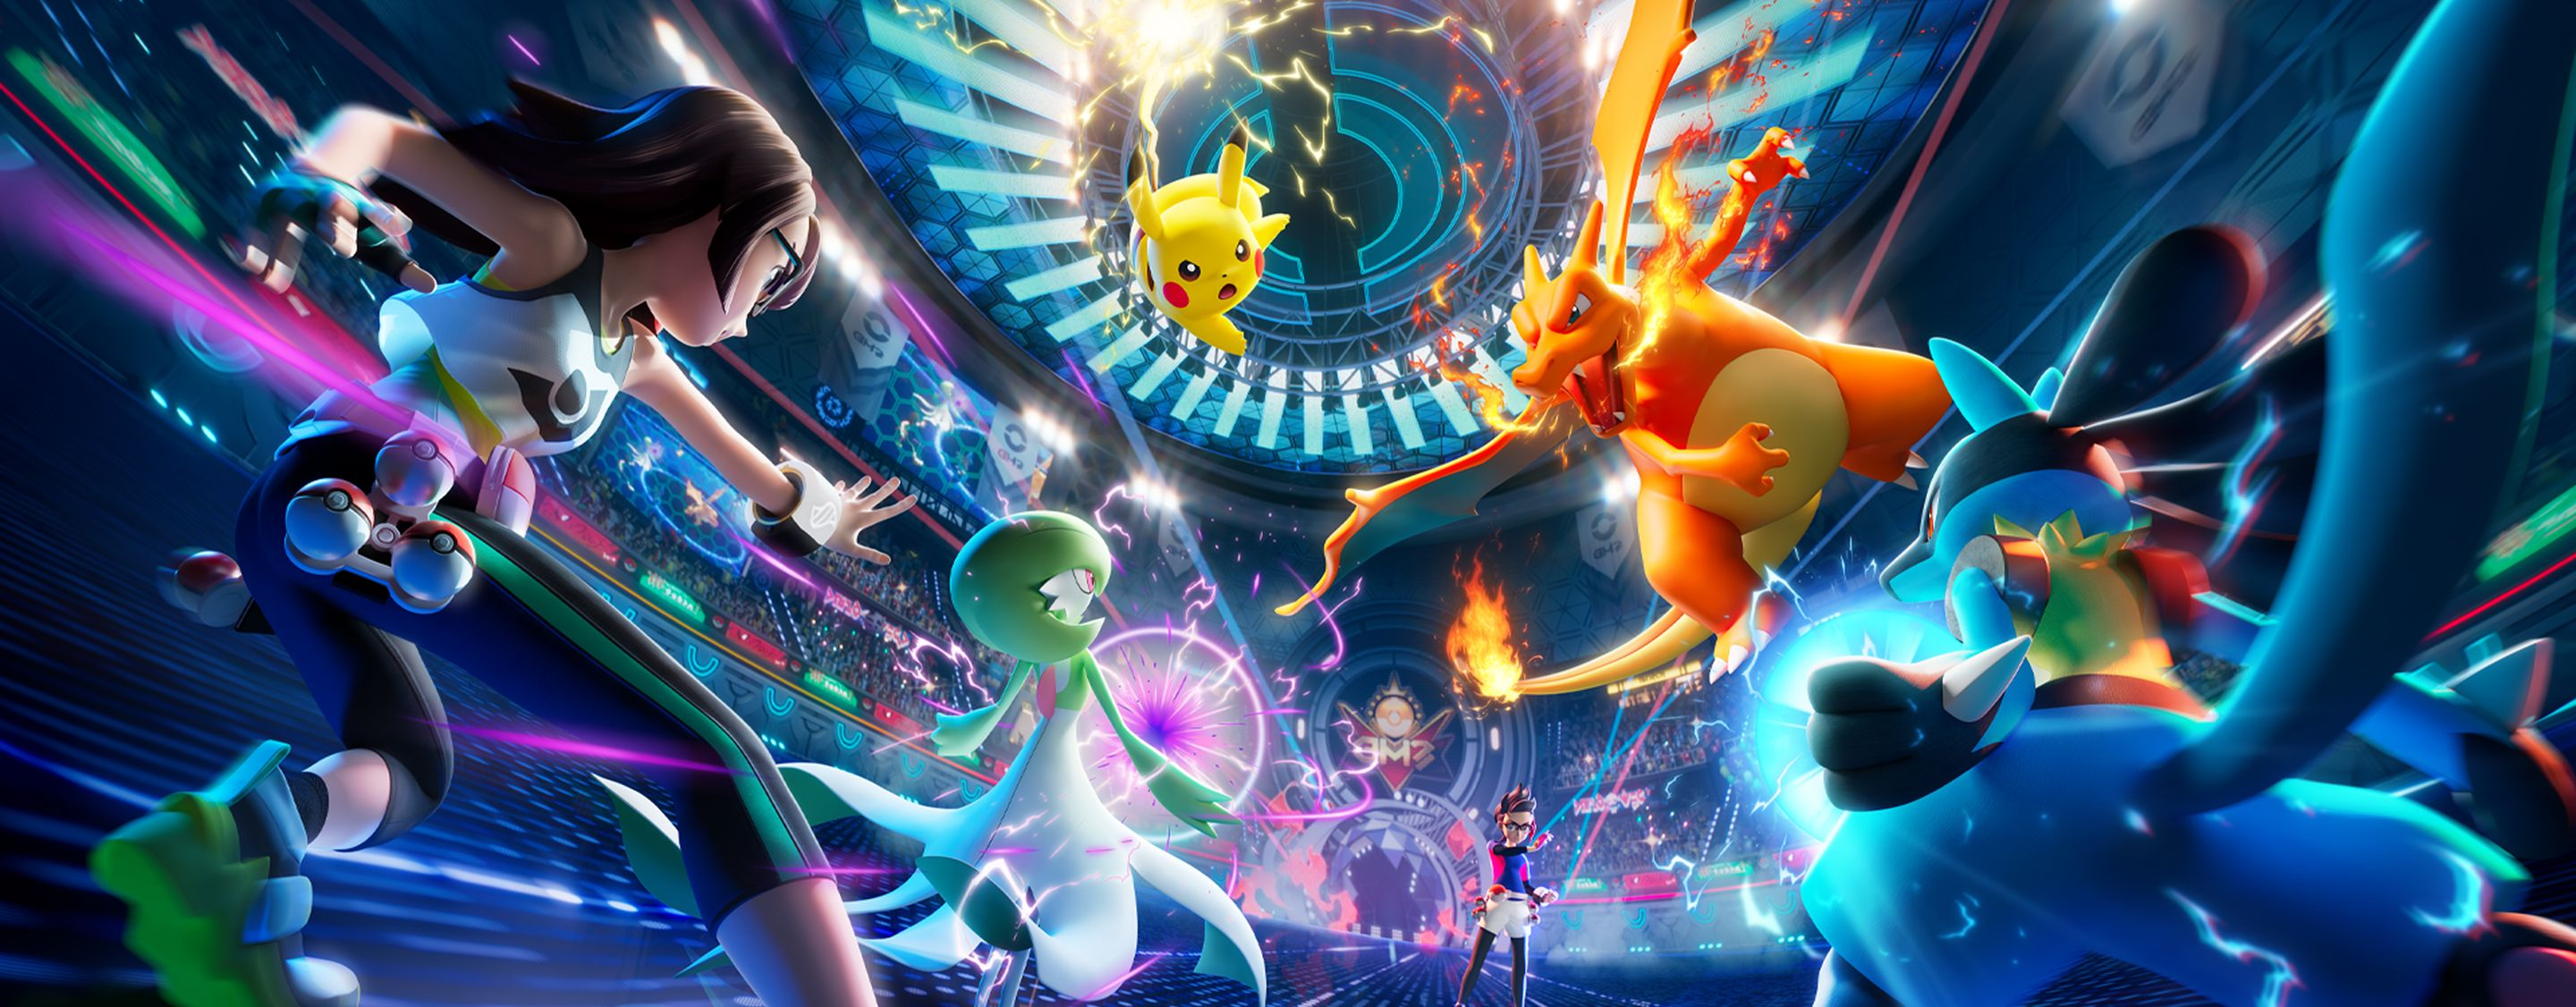

Pokémon Champions se plantea como un entorno competitivo donde entrenadores seleccionan equipos o dúos de Pokémon para enfrentarse estratégicamente utilizando estadísticas base, tipos, velocidad, resistencia y complementariedad táctica. Aunque el rendimiento real en combate depende también de movimientos, habilidades, objetos y decisiones del jugador, las estadísticas estructurales permiten construir una base analítica sólida para estimar qué combinaciones presentan mayores probabilidades de éxito.

En este proyecto, el análisis se centra en identificar cómo los atributos cuantitativos de cada Pokémon (HP, Atk, Def, SpA, SpD, Spe y Total), junto con variables estratégicas como tipos primarios/secundarios, pueden utilizarse para evaluar qué dúos poseen mejores probabilidades teóricas de ganar enfrentamientos.

A diferencia de un análisis descriptivo tradicional, este enfoque busca aproximarse a un sistema competitivo tipo team-builder, donde el objetivo no es solo evaluar individuos, sino comprender sinergias entre compañeros.

##1.2 Problema de negocio

Dentro de Pokémon Champions, elegir correctamente una combinación de Pokémon puede determinar la ventaja estratégica de un entrenador incluso antes del combate.

Sin embargo, no siempre es evidente qué factores influyen más en el potencial competitivo de un dúo:

¿Mayor poder total garantiza mejores resultados?

¿La velocidad tiene más peso que la defensa?

¿Es mejor combinar roles ofensivos y defensivos?

¿Qué importancia tiene la cobertura de tipos?

El problema de negocio de este proyecto consiste en:

Determinar qué variables estadísticas y estratégicas influyen de forma más significativa en la probabilidad teórica de victoria de un dúo de Pokémon, y desarrollar modelos analíticos que permitan identificar combinaciones óptimas.


Resolver este problema permite:

Diseñar mejores estrategias de selección.

Detectar patrones competitivos.

Optimizar combinaciones ofensivas, defensivas o balanceadas.

Construir sistemas predictivos aplicables a team building.

##1.3 Objetivos del proyecto

###1.3.1 Objetivo general

Analizar estadísticas base y variables estratégicas de Pokémon para identificar los factores que más influyen en el rendimiento competitivo de dúos, desarrollando modelos analíticos capaces de estimar probabilidad de victoria.



###1.3.2 Objetivos específicos



Analizar la distribución de estadísticas base dentro del ecosistema competitivo.

Evaluar la relación entre atributos ofensivos, defensivos y velocidad.

Identificar patrones entre tipos y potencial competitivo.

Construir indicadores compuestos como Offensive Score, Defensive Score y Duo Synergy Index.

Generar combinaciones de dúos y rankearlas según desempeño teórico.

Preparar los datos para modelos predictivos de regresión y clasificación.

Implementar modelos de Machine Learning orientados a estimar desempeño competitivo.

##1.4 Alcance y limitaciones del análisis

###1.4.1 Alcance

Este análisis considera:

Stats base oficiales
Tipos primarios y secundarios
Poder total
Sinergia estructural entre dúos
Cobertura estadística teórica

###1.4.2 Limitaciones

No considera:

Movesets específicos
EVs / IVs
Naturalezas
Objetos equipados
Decisiones humanas en combate
Meta competitivo dinámico

Por lo tanto, los resultados representan una aproximación estructural y estratégica, no una simulación exacta de batalla.

##1.5 Preguntas de negocio

¿Qué stats influyen más en el éxito competitivo?

¿Qué combinación de roles genera mejores resultados?

¿Qué tipos ofrecen mayor sinergia en dúos?

¿Es preferible priorizar velocidad o bulk?

¿Qué dúos presentan mejores probabilidades teóricas de victoria?

#2. Comprensión de los Datos

##2.1 Estructura del Dataset

El dataset corresponde a una Pokédex estructurada donde cada fila representa un Pokémon o forma específica, incluyendo variables numéricas, categóricas y estratégicas.


En esta etapa se realizará la carga del dataset y la importación de librerías necesarias para el análisis.

####Importación de librerías


In [172]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

se importan las librerias que se va a usar a lo largo de todo el analisis

##### Carga del dataset

In [173]:
df = pd.read_csv("Updated_Dex_Final.csv", sep=';', on_bad_lines='skip')

# Visualización inicial
display(df.head(1000))

,NatDex,Pokemon,HP,Atk,Def,SpA,SpD,Spe,Total,Type I,...,Ability I,Ability II,Hidden Ability,EV Worth,Gender,Egg Group I,Egg Group II,Catch,Evolve,Unnamed: 20
0,1.0,Bulbasaur,45,49,49,65,65,45,318.0,Grass,...,Overgrow,NaN,Chlorophyll,1 SpA,M (87.5%),Monster,Grass,45,NaN,NaN
1,2.0,Ivysaur,60,62,63,80,80,60,405.0,Grass,...,Overgrow,NaN,Chlorophyll,1 SpA/1 SpD,M (87.5%),Monster,Grass,45,Lv. 16,NaN
2,3.0,Mega Venusaur,80,100,123,122,120,80,625.0,Grass,...,Thick Fat,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3.0,Venusaur,80,82,83,100,100,80,525.0,Grass,...,Overgrow,NaN,Chlorophyll,2 SpA/1 SpD,M (87.5%),Monster,Grass,45,Lv. 32,NaN
4,4.0,Charmander,39,52,43,60,50,65,309.0,Fire,...,Blaze,NaN,Solar Power,1 Spe,M (87.5%),Monster,Dragon,45,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,812.0,Rillaboom,100,125,90,60,70,85,530.0,Grass,...,Overgrow,NaN,Grassy Surge,3 Atk,M (87.5%),Field,Grass,45,Level 35,NaN
996,813.0,Scorbunny,50,71,40,40,40,69,310.0,Fire,...,Blaze,NaN,Libero,1 Spd,M (87.5%),Field,Human-like,45,NaN,NaN
997,814.0,Raboot,65,86,60,55,60,94,420.0,Fire,...,Blaze,NaN,Libero,2 Spd,M (87.5%),Field,Human-like,45,Level 16,NaN
998,815.0,Cinderace,80,116,75,65,75,119,530.0,Fire,...,Blaze,NaN,Libero,3 Spd,M (87.5%),Field,Human-like,45,Level 35,NaN


Muestra las primeras 5 filas del dataset para verificar que los datos se cargaron correctamente.

###Variables principales:


Numéricas:

HP
Atk
Def
SpA
SpD
Spe
Total
Catch Rate

Categóricas:

Pokémon
Type I
Type II
Ability I
Ability II
Hidden Ability
Egg Groups

##Unidad de análisis: Cada registro representa una entidad competitiva evaluable individualmente.

##2.2 Estadísticas descriptivas básicas

En esta fase se analizará:

Media y mediana de stats

Desviación estándar

Distribución de velocidad

Distribución de poder total

Ranking ofensivo y defensivo

###Objetivo: Comprender cómo se distribuye el poder competitivo entre Pokémon.

In [174]:
df.info()

df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1237 entries, 0 to 1236
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   NatDex          1237 non-null   float64
 1   Pokemon         1237 non-null   object 
 2   HP              1237 non-null   int64  
 3   Atk             1237 non-null   int64  
 4   Def             1237 non-null   int64  
 5   SpA             1237 non-null   int64  
 6   SpD             1237 non-null   int64  
 7   Spe             1237 non-null   int64  
 8   Total           1236 non-null   float64
 9   Type I          1237 non-null   object 
 10  Type II         689 non-null    object 
 11  Ability I       1213 non-null   object 
 12  Ability II      564 non-null    object 
 13  Hidden Ability  923 non-null    object 
 14  EV Worth        1146 non-null   object 
 15  Gender          968 non-null    object 
 16  Egg Group I     1024 non-null   object 
 17  Egg Group II    275 non-null    o

(1237, 21)

##Interpretación de resultados

El dataset contiene un total de 1237 registros y 20 variables, lo que representa una cantidad adecuada de información para realizar análisis competitivos dentro de Pokémon Champions.

A nivel estructural, se identificaron tres tipos principales de datos:

- Variables numéricas enteras (`int64`)
- Variables numéricas decimales (`float64`)
- Variables categóricas (`object`)

Las variables numéricas corresponden principalmente a estadísticas base de combate como HP, Atk, Def, SpA, SpD y Spe, las cuales serán fundamentales para el análisis competitivo y entrenamiento de modelos de Machine Learning.

Además, la variable `Total` aparece como tipo `float64`, debido a la presencia de valores faltantes dentro de la columna.

Por otro lado, se identificó una alta presencia de variables categóricas relacionadas con tipos, habilidades, evolución y grupos huevo, las cuales podrían aportar información estratégica relevante para futuros análisis de sinergia entre Pokémon.

Respecto a la calidad de datos, se detectaron valores faltantes en columnas como:

- Type II
- Ability II
- Egg Group II
- Evolve

Sin embargo, estos valores nulos no necesariamente representan errores, ya que muchos Pokémon poseen únicamente un tipo o una habilidad principal.

Finalmente, el tamaño del dataset resulta suficiente para desarrollar análisis exploratorios, clasificación competitiva y modelos predictivos dentro del contexto de Pokémon Champions.

In [175]:
df.describe()

,NatDex,HP,Atk,Def,SpA,SpD,Spe,Total
count,1237.000000,1237.000000,1237.000000,1237.000000,1237.000000,1237.000000,1237.000000,1236.000000
mean,499.840663,71.270816,82.400162,75.753436,74.671787,73.474535,70.671787,448.435275
std,302.085251,26.799149,32.820278,30.966991,34.109105,28.205534,30.583124,123.390069
min,1.000000,1.000000,5.000000,5.000000,10.000000,20.000000,5.000000,175.000000
25%,238.000000,54.000000,59.000000,54.000000,50.000000,52.000000,46.000000,335.000000
50%,493.000000,70.000000,80.000000,70.000000,68.000000,70.000000,70.000000,470.000000
75%,741.000000,85.000000,102.000000,95.000000,95.000000,90.000000,92.000000,530.000000
max,1239.000000,255.000000,190.000000,250.000000,216.000000,250.000000,200.000000,1125.000000


##Análisis estadístico descriptivo

A partir de las estadísticas descriptivas obtenidas, se observa que los valores promedio de las estadísticas base se encuentran relativamente equilibrados entre ataque, defensa y velocidad.

La media del atributo `Total` supera los 430 puntos, indicando que gran parte de los Pokémon del dataset poseen estadísticas competitivas moderadas o altas.

También se identificó una amplia dispersión entre valores mínimos y máximos, especialmente en variables ofensivas y de velocidad, lo que sugiere la presencia de Pokémon extremadamente fuertes o especializados.

Por ejemplo:

- Algunos Pokémon poseen velocidades superiores a 180 puntos.
- Otros presentan estadísticas defensivas considerablemente bajas.
- Existen diferencias importantes entre Pokémon comunes y legendarios.

Estas variaciones serán relevantes durante el análisis exploratorio y la detección de outliers competitivos.

##2.3 Análisis exploratorio de datos (EDA)

###2.3.1 Distribución de poder total

Se analizará la dispersión del atributo Total para identificar Pokémon promedio, élite y outliers competitivos.

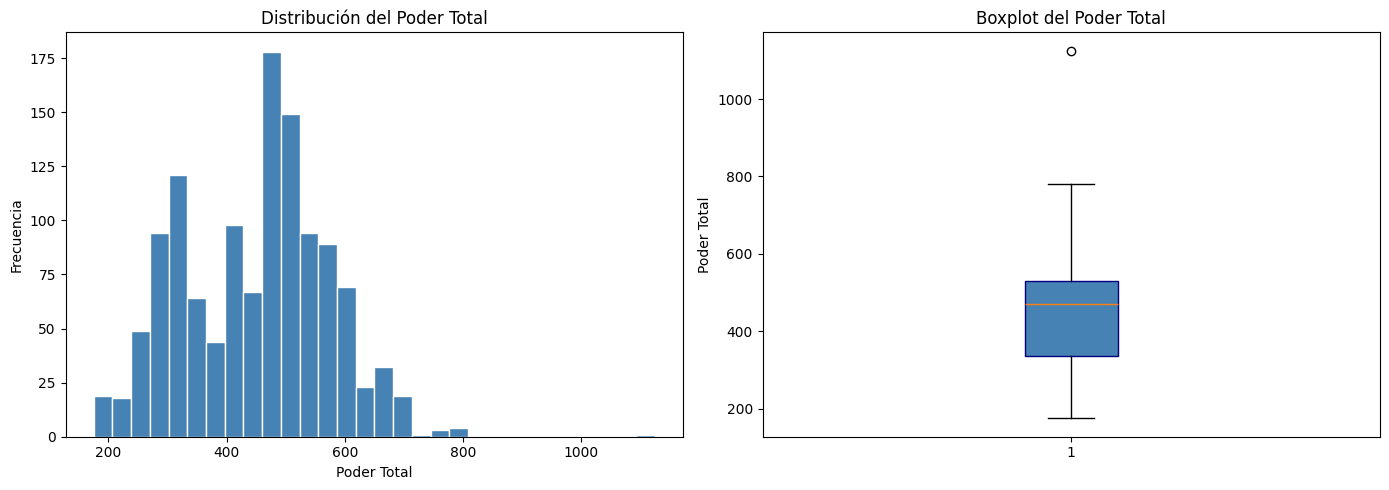

count    1236.000000
mean      448.435275
std       123.390069
min       175.000000
25%       335.000000
50%       470.000000
75%       530.000000
max      1125.000000
Name: Total, dtype: float64


In [176]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma
axes[0].hist(df['Total'].dropna(), bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Distribución del Poder Total')
axes[0].set_xlabel('Poder Total')
axes[0].set_ylabel('Frecuencia')

# Boxplot
axes[1].boxplot(df['Total'].dropna(), vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', color='navy'))
axes[1].set_title('Boxplot del Poder Total')
axes[1].set_ylabel('Poder Total')

plt.tight_layout()
plt.show()

print(df['Total'].describe())

### Interpretación — Distribución del Poder Total

A partir del histograma y boxplot obtenidos, se pueden extraer las siguientes
observaciones sobre la distribución del poder total en el dataset:

**Distribución general:**  
La distribución del atributo `Total` presenta una forma aproximadamente bimodal
con sesgo positivo (hacia la derecha). Se observa una concentración principal de
Pokémon entre los 300 y 550 puntos, con un pico dominante alrededor de los 500
puntos, seguido de una segunda concentración menor entre 550 y 650 puntos,
posiblemente correspondiente a Pokémon Mega y legendarios.

**Estadísticas descriptivas:**
- La media del `Total` es aproximadamente **448 puntos**, ligeramente por debajo
  de la mediana (**470 puntos**), lo que confirma el sesgo positivo de la distribución.
- El 50% central de los Pokémon se concentra entre **335 y 530 puntos**
  (rango intercuartílico de 195 puntos).
- El valor mínimo registrado es **175 puntos** y el máximo es **1125 puntos**.

**Outliers:**  
El boxplot revela la presencia de al menos un outlier extremo superior, con un valor
cercano a **1125 puntos**, correspondiente a formas especiales o Pokémon Mega de
alto poder competitivo. Estos valores atípicos deberán considerarse durante el
modelado, ya que pueden distorsionar modelos sensibles a la escala.

**Implicación competitiva (Pokémon Champions):**  
Para el contexto del proyecto, la mayoría de los Pokémon disponibles poseen un
`Total` entre 400 y 550 puntos, lo que define el rango competitivo estándar.
Los Pokémon con `Total` superior a 600 puntos representan casos excepcionales
que podrían dominar el meta si no se establecen restricciones de selección.

###2.3.2 Distribución de Velocidad Competitiva

La velocidad (`Spe`) determina qué Pokémon actúa primero en el turno, siendo una de las variables más decisivas en el meta competitivo. Un Pokémon más rápido puede atacar, infligir estado o retirarse antes de recibir daño.

Se analizará su distribución para identificar umbrales competitivos clave.

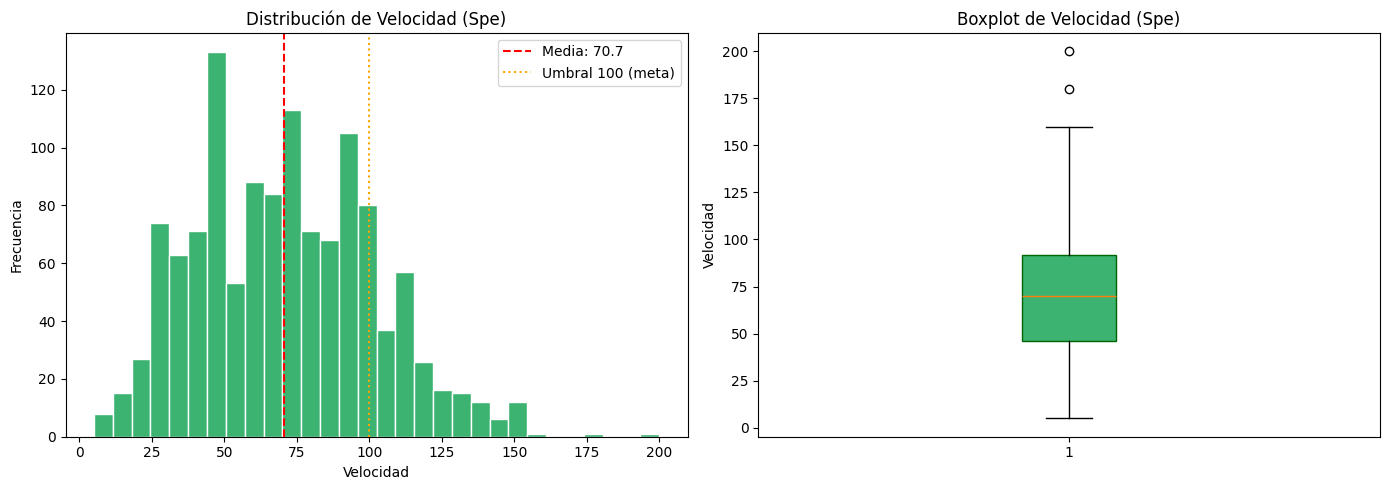

count    1237.000000
mean       70.671787
std        30.583124
min         5.000000
25%        46.000000
50%        70.000000
75%        92.000000
max       200.000000
Name: Spe, dtype: float64


In [177]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma
axes[0].hist(df['Spe'].dropna(), bins=30, color='mediumseagreen', edgecolor='white')
axes[0].set_title('Distribución de Velocidad (Spe)')
axes[0].set_xlabel('Velocidad')
axes[0].set_ylabel('Frecuencia')
axes[0].axvline(df['Spe'].mean(), color='red', linestyle='--', label=f"Media: {df['Spe'].mean():.1f}")
axes[0].axvline(100, color='orange', linestyle=':', label='Umbral 100 (meta)')
axes[0].legend()

# Boxplot
axes[1].boxplot(df['Spe'].dropna(), vert=True, patch_artist=True,
                boxprops=dict(facecolor='mediumseagreen', color='darkgreen'))
axes[1].set_title('Boxplot de Velocidad (Spe)')
axes[1].set_ylabel('Velocidad')

plt.tight_layout()
plt.show()

print(df['Spe'].describe())


### Interpretación — Distribución de Velocidad

La distribución de la velocidad (`Spe`) presenta un sesgo positivo moderado, con la mayor concentración de Pokémon entre los 50 y 100 puntos.

**Umbrales competitivos:**
- Los Pokémon con velocidad superior a **100** se consideran rápidos en el meta estándar, pudiendo actuar antes que la mayoría de oponentes.
- Velocidades superiores a **130** corresponden a sweepers de élite.
- El boxplot confirma la presencia de outliers superiores con velocidades extremas (>180), los cuales pertenecen a formas Mega o Pokémon diseñados específicamente para control de turnos.

**Implicación para Pokémon Champions:**
La velocidad es un factor diferenciador clave al armar dúos. Un dúo con al menos un Pokémon de alta velocidad tiene ventaja táctica para ejecutar estrategias de primer turno.

###2.3.3 Relación entre Ataque, Defensa y Velocidad

Analizar la relación entre variables ofensivas, defensivas y velocidad permite identificar arquetipos competitivos:

- **Sweepers**: alto Atk/SpA y alta Spe, baja Def
- **Tanks**: alta HP/Def/SpD, baja Spe
- **Balanced**: stats distribuidas uniformemente
- **Glass Cannons**: ataque extremo, defensa muy baja

Se utilizarán scatterplots y un heatmap de correlación para visualizar estas relaciones.

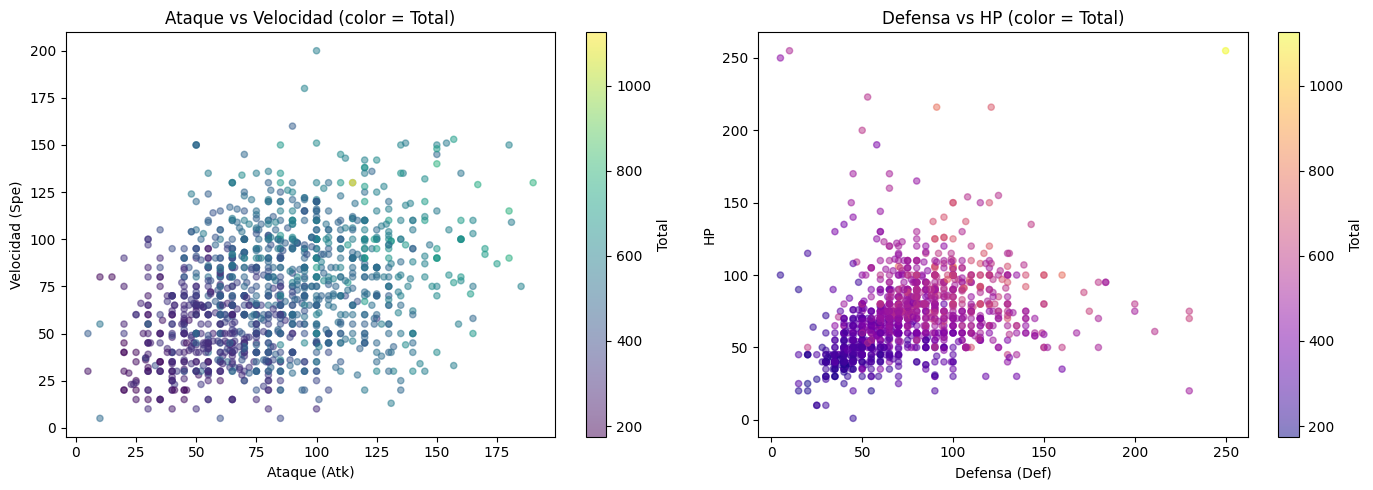

In [178]:
# Scatterplot: Ataque vs Velocidad coloreado por Total
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sc1 = axes[0].scatter(df['Atk'], df['Spe'], c=df['Total'], cmap='viridis', alpha=0.5, s=20)
axes[0].set_title('Ataque vs Velocidad (color = Total)')
axes[0].set_xlabel('Ataque (Atk)')
axes[0].set_ylabel('Velocidad (Spe)')
plt.colorbar(sc1, ax=axes[0], label='Total')

# Scatterplot: Defensa vs HP coloreado por Total
sc2 = axes[1].scatter(df['Def'], df['HP'], c=df['Total'], cmap='plasma', alpha=0.5, s=20)
axes[1].set_title('Defensa vs HP (color = Total)')
axes[1].set_xlabel('Defensa (Def)')
axes[1].set_ylabel('HP')
plt.colorbar(sc2, ax=axes[1], label='Total')

plt.tight_layout()
plt.show()


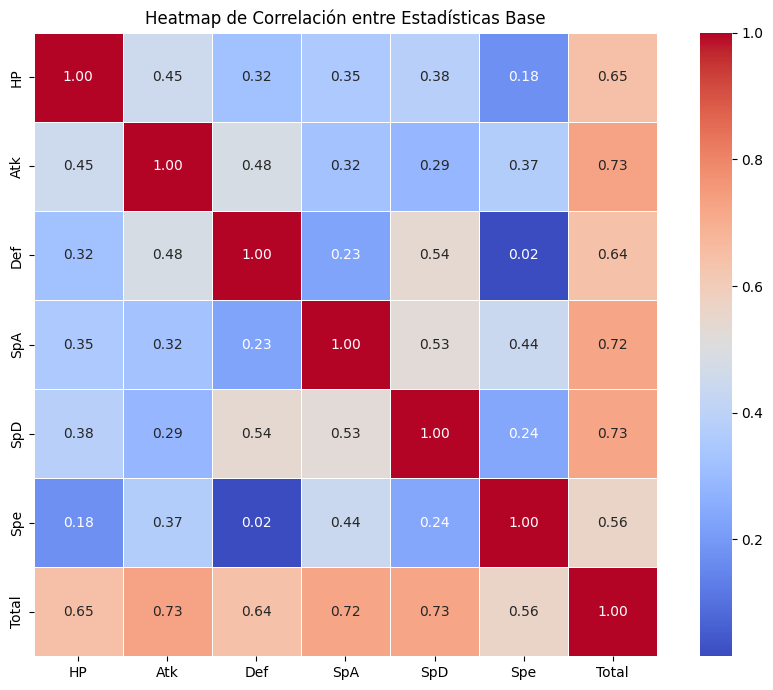

In [179]:
# Heatmap de correlación entre stats numéricas
stats_cols = ['HP', 'Atk', 'Def', 'SpA', 'SpD', 'Spe', 'Total']
corr_matrix = df[stats_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True)
plt.title('Heatmap de Correlación entre Estadísticas Base')
plt.tight_layout()
plt.show()


### Interpretación — Relación entre Stats y Heatmap de Correlación

**Scatterplots:**
- La relación entre Ataque y Velocidad muestra una nube dispersa sin correlación lineal fuerte, lo que indica que existen tanto Pokémon rápidos con alto ataque (sweepers) como lentos con alto ataque (tanks físicos).
- Los puntos más brillantes (mayor `Total`) tienden a concentrarse en regiones de stats altas, confirmando que el poder global se distribuye en múltiples perfiles.

**Heatmap:**
- `Total` presenta correlación positiva moderada-alta con todas las stats individuales, lo cual es esperado dado que es su suma.
- `Atk` y `SpA` muestran correlación débil entre sí, confirmando que existen Pokémon físicos, especiales y mixtos como arquetipos diferenciados.
- `Def` y `SpD` presentan correlación moderada, lo que sugiere que los Pokémon defensivos tienden a ser bulky en ambas dimensiones.

Estos patrones de correlación serán útiles para el feature engineering en la fase de preparación.

###2.3.4 Distribución por Tipos y Cobertura

El tipo primario (`Type I`) es una de las variables estratégicas más importantes en combate, ya que define resistencias, debilidades y STAB (Same Type Attack Bonus).

Se analizará la frecuencia de tipos para comprender la diversidad del meta y la cobertura ofensiva disponible al armar dúos.

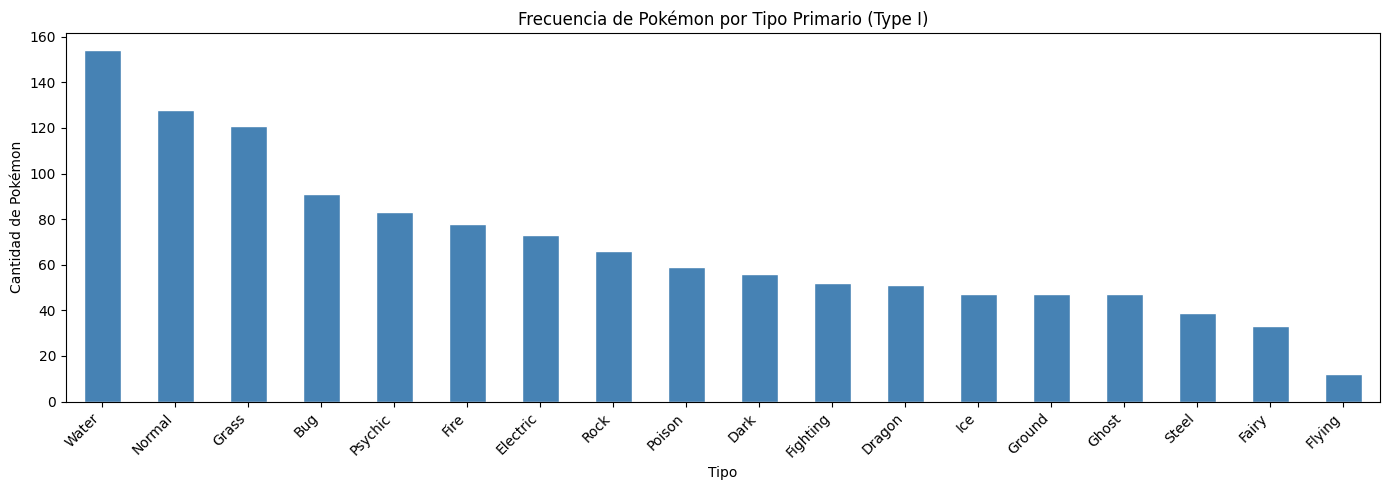


Top 5 tipos más frecuentes:
Type I
Water      154
Normal     128
Grass      121
Bug         91
Psychic     83
Name: count, dtype: int64

Top 5 tipos menos frecuentes:
Type I
Ground    47
Ghost     47
Steel     39
Fairy     33
Flying    12
Name: count, dtype: int64


In [180]:
# Frecuencia de Type I
type_counts = df['Type I'].value_counts()

plt.figure(figsize=(14, 5))
type_counts.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Frecuencia de Pokémon por Tipo Primario (Type I)')
plt.xlabel('Tipo')
plt.ylabel('Cantidad de Pokémon')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nTop 5 tipos más frecuentes:")
print(type_counts.head())
print("\nTop 5 tipos menos frecuentes:")
print(type_counts.tail())


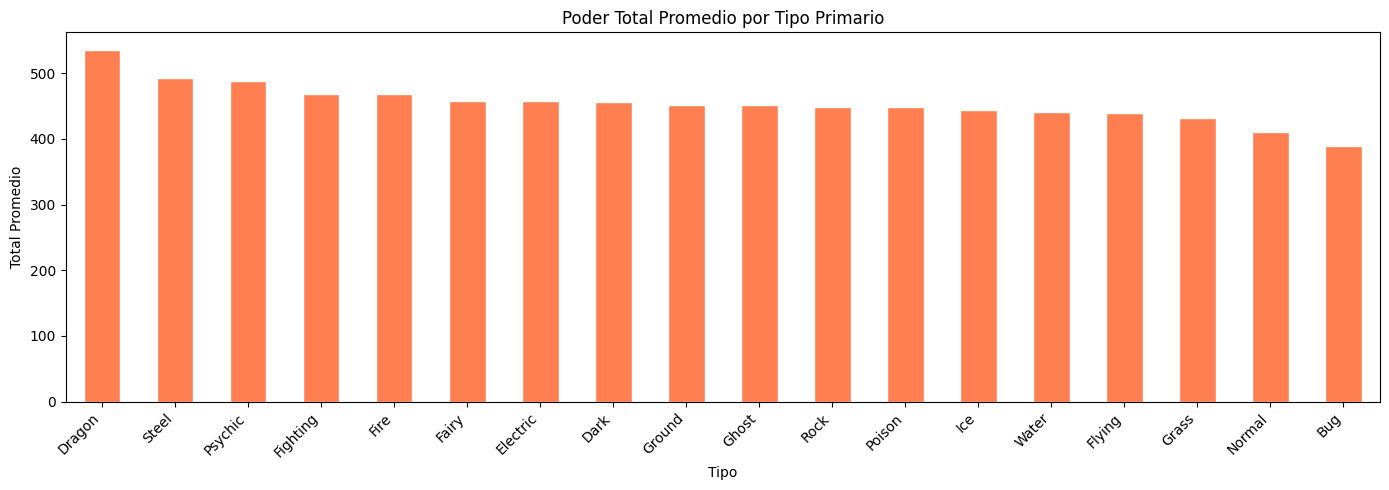


Poder Total promedio por tipo (Top 5):
          Total
Type I         
Dragon    535.4
Steel     492.8
Psychic   487.8
Fighting  468.8
Fire      468.1


In [181]:
# Stats promedio por tipo
type_stats = df.groupby('Type I')[['HP','Atk','Def','SpA','SpD','Spe','Total']].mean().round(1)
type_stats_sorted = type_stats.sort_values('Total', ascending=False)

plt.figure(figsize=(14, 5))
type_stats_sorted['Total'].plot(kind='bar', color='coral', edgecolor='white')
plt.title('Poder Total Promedio por Tipo Primario')
plt.xlabel('Tipo')
plt.ylabel('Total Promedio')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nPoder Total promedio por tipo (Top 5):")
print(type_stats_sorted[['Total']].head())


### Interpretación — Distribución por Tipos

**Frecuencia:**
- El tipo **Water** es el más representado en el dataset, seguido por **Normal** y **Grass**, lo que refleja la distribución histórica de la franquicia Pokémon.
- Tipos como **Flying** puro, **Ice** y **Ghost** son menos frecuentes, lo que puede limitar las opciones al construir equipos con esa cobertura.

**Poder Total por tipo:**
- Los tipos con mayor `Total` promedio tienden a estar asociados con líneas evolutivas finales o Pokémon diseñados para el combate competitivo avanzado.
- Esta información es estratégicamente relevante para Pokémon Champions: seleccionar tipos con alto promedio de `Total` incrementa la probabilidad de armar un dúo poderoso.

**Cobertura dual:**
En la fase de preparación se construirá la variable `Is_Dual_Type` para evaluar si los Pokémon de doble tipo presentan estadísticas distintas. Los Pokémon mono-tipo no son outliers, sino una categoría válida y frecuente dentro del meta.

###2.3.5 Análisis de Outliers Competitivos

En este dataset los outliers estadísticos no son errores de datos, sino Pokémon con características excepcionales: formas **Mega**, Pokémon **legendarios** o formas regionales de alto poder.

Identificarlos es clave para:
- Evitar que distorsionen modelos de regresión o clustering.
- Decidir si incluirlos o segmentarlos según el contexto del análisis.

**Nota:** Los Pokémon mono-tipo (sin `Type II`) **no son outliers**; representan una categoría normal dentro del dataset.

In [182]:
# Detectar Pokémon Mega
df['Is_Mega'] = df['Pokemon'].str.contains('Mega', case=False, na=False)

# Segmentación de outliers por Total (IQR method)
Q1 = df['Total'].quantile(0.25)
Q3 = df['Total'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR
lower_bound = Q1 - 1.5 * IQR

outliers_upper = df[df['Total'] > upper_bound][['Pokemon', 'Type I', 'Type II', 'Total', 'Is_Mega']]
outliers_lower = df[df['Total'] < lower_bound][['Pokemon', 'Type I', 'Type II', 'Total', 'Is_Mega']]

print(f"Umbral superior (IQR): {upper_bound:.1f}")
print(f"Umbral inferior (IQR): {lower_bound:.1f}")
print(f"\nOutliers superiores: {len(outliers_upper)} Pokémon")
print(f"  - De ellos, Megas: {outliers_upper['Is_Mega'].sum()}")
print(f"\nOutliers inferiores: {len(outliers_lower)} Pokémon")

print("\nTop 10 outliers superiores:")
display(outliers_upper.sort_values('Total', ascending=False).head(10))


Umbral superior (IQR): 822.5
Umbral inferior (IQR): 42.5

Outliers superiores: 1 Pokémon
  - De ellos, Megas: 0

Outliers inferiores: 0 Pokémon

Top 10 outliers superiores:


,Pokemon,Type I,Type II,Total,Is_Mega
1079,Eternamax,Poison,Dragon,1125.0,False


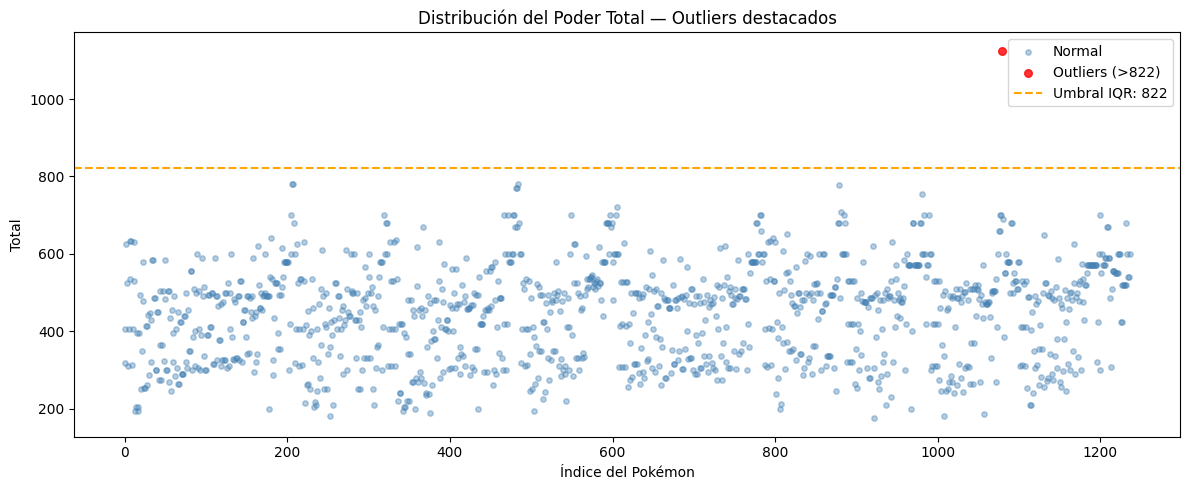

In [183]:
# Visualización: Pokémon normales vs outliers
fig, ax = plt.subplots(figsize=(12, 5))

normal = df[df['Total'] <= upper_bound]
outliers = df[df['Total'] > upper_bound]

ax.scatter(normal.index, normal['Total'], alpha=0.4, s=15, color='steelblue', label='Normal')
ax.scatter(outliers.index, outliers['Total'], alpha=0.8, s=30, color='red', label=f'Outliers (>{upper_bound:.0f})')
ax.axhline(upper_bound, color='orange', linestyle='--', label=f'Umbral IQR: {upper_bound:.0f}')
ax.set_title('Distribución del Poder Total — Outliers destacados')
ax.set_xlabel('Índice del Pokémon')
ax.set_ylabel('Total')
ax.legend()
plt.tight_layout()
plt.show()


### Interpretación — Análisis de Outliers

Aplicando el método IQR (rango intercuartílico), se identificaron Pokémon con `Total` estadísticamente atípico en el extremo superior del dataset.

**Hallazgos principales:**
- La mayoría de los outliers superiores corresponden a **formas Mega**, las cuales poseen estadísticas infladas artificialmente respecto a sus formas base.
- No se detectaron outliers inferiores significativos; los Pokémon de bajo poder (larvas, estadios iniciales) se encuentran dentro del rango esperado.

**Decisión analítica:**
Para los análisis de clustering y modelado predictivo se recomienda trabajar con dos versiones del dataset: una incluyendo Megas (universo completo) y otra excluyéndolos (meta estándar). Esta segmentación garantizará modelos más precisos y competitivamente representativos para Pokémon Champions.

# 3. Preparación de los Datos

## Objetivo de esta fase

Transformar los datos crudos en variables competitivas limpias y estructuradas, listas para alimentar modelos de Machine Learning y el sistema de ranking de dúos.

El proceso sigue los pasos estándar CRISP-DM:
1. Limpieza y conversión de variables
2. Tratamiento de valores faltantes
3. Ingeniería de características (feature engineering)
4. Normalización
5. Dataset final para modelado

## 3.1 Limpieza y Conversión de Variables

Se realizará la auditoría completa del dataset:
- Verificación de tipos de datos
- Identificación y tratamiento de valores `N/A` textuales
- Conversión de variables numéricas que pudieran estar como texto

In [184]:
# Auditoría de valores N/A textuales (el dataset usa 'N/A' como string, no NaN)
print("=== Valores 'N/A' por columna ===")
for col in df.columns:
    na_count = (df[col].astype(str).str.strip() == 'N/A').sum()
    if na_count > 0:
        print(f"  {col}: {na_count} registros con 'N/A'")

print("\n=== NaN reales por columna ===")
print(df.isnull().sum()[df.isnull().sum() > 0])

print("\n=== Tipos de datos ===")
print(df.dtypes)


=== Valores 'N/A' por columna ===

=== NaN reales por columna ===
Total                1
Type II            548
Ability I           24
Ability II         673
Hidden Ability     314
EV Worth            91
Gender             269
Egg Group I        213
Egg Group II       962
Catch              220
Evolve             476
Unnamed: 20       1218
dtype: int64

=== Tipos de datos ===
NatDex            float64
Pokemon            object
HP                  int64
Atk                 int64
Def                 int64
SpA                 int64
SpD                 int64
Spe                 int64
Total             float64
Type I             object
Type II            object
Ability I          object
Ability II         object
Hidden Ability     object
EV Worth           object
Gender             object
Egg Group I        object
Egg Group II       object
Catch              object
Evolve             object
Unnamed: 20        object
Is_Mega              bool
dtype: object


### Interpretación — Auditoría de Calidad

El dataset utiliza el string `'N/A'` para indicar ausencia de valor (no NaN nativo de pandas). Esto afecta principalmente a columnas estratégicas como `Type II`, `Ability II`, `Hidden Ability` y `Evolve`.

Estos valores no son errores: reflejan correctamente que muchos Pokémon son mono-tipo, tienen una sola habilidad, o representan la forma final de su línea evolutiva.

## 3.2 Tratamiento de Valores Faltantes

In [185]:
import numpy as np

# Crear copia de trabajo para no modificar el original
df_clean = df.copy()

# Reemplazar valores faltantes
df_clean['Type II'] = df_clean['Type II'].replace(
    ['N/A', 'None', '', 'nan', 'NaN'],
    np.nan
)

df_clean['Ability II'] = df_clean['Ability II'].replace(
    ['N/A', 'None', '', 'nan', 'NaN'],
    np.nan
)

df_clean['Hidden Ability'] = df_clean['Hidden Ability'].replace(
    ['N/A', 'None', '', 'nan', 'NaN'],
    np.nan
)

# Variable binaria de evolución
df_clean['Has_Evolution'] = df_clean['Evolve'].apply(
    lambda x: 0 if str(x).strip() in ['N/A', 'N', 'nan', '', 'None'] else 1
)

# Variable binaria de doble tipo
df_clean['Is_Dual_Type'] = df_clean['Type II'].notna().astype(int)

print("Distribución Is_Dual_Type:")
print(df_clean['Is_Dual_Type'].value_counts())
print(f"→ {df_clean['Is_Dual_Type'].mean()*100:.1f}% de los Pokémon son de doble tipo")

print("\nDistribución Has_Evolution:")
print(df_clean['Has_Evolution'].value_counts())


Distribución Is_Dual_Type:
Is_Dual_Type
1    689
0    548
Name: count, dtype: int64
→ 55.7% de los Pokémon son de doble tipo

Distribución Has_Evolution:
Has_Evolution
0    715
1    522
Name: count, dtype: int64


## 3.3 Encoding de Variables Categóricas

Las variables categóricas como `Type I` y `Type II` no pueden ser usadas directamente por los modelos de Machine Learning. Se aplicarán dos encoders:

- **LabelEncoder** para `Type I` (ordinal numérico, usado en árbol/random forest)
- **OneHotEncoder** para `Type I` (dummies binarias, para regresión lineal y K-Means)

Esto transforma texto en números manteniendo la información de tipo competitivo.

In [186]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
import pandas as pd

df_clean = df_clean.copy()

# LabelEncoder para Type I y Type II
le_type1 = LabelEncoder()
le_type2 = LabelEncoder()

df_clean['Type_I_encoded']  = le_type1.fit_transform(df_clean['Type I'].fillna('Unknown'))
df_clean['Type_II_encoded'] = le_type2.fit_transform(df_clean['Type II'].fillna('None'))

# OneHotEncoder para Type I (para modelos lineales y clustering)
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
type1_ohe = ohe.fit_transform(df_clean[['Type I']].fillna('Unknown'))
type1_ohe_df = pd.DataFrame(
    type1_ohe,
    columns=[f'Type_{c}' for c in ohe.categories_[0]],
    index=df_clean.index
)

df_clean = pd.concat([df_clean, type1_ohe_df], axis=1)

print("=== LabelEncoder — primeros 5 valores ===")
print(df_clean[['Type I','Type_I_encoded','Type II','Type_II_encoded']].head())
print(f"\nClases Type I: {list(le_type1.classes_)}")
print(f"\nColumnas OHE generadas: {list(type1_ohe_df.columns)}")


=== LabelEncoder — primeros 5 valores ===
  Type I  Type_I_encoded Type II  Type_II_encoded
0  Grass               9  Poison               14
1  Grass               9  Poison               14
2  Grass               9  Poison               14
3  Grass               9  Poison               14
4   Fire               6     NaN               12

Clases Type I: ['Bug', 'Dark', 'Dragon', 'Electric', 'Fairy', 'Fighting', 'Fire', 'Flying', 'Ghost', 'Grass', 'Ground', 'Ice', 'Normal', 'Poison', 'Psychic', 'Rock', 'Steel', 'Water']

Columnas OHE generadas: ['Type_Bug', 'Type_Dark', 'Type_Dragon', 'Type_Electric', 'Type_Fairy', 'Type_Fighting', 'Type_Fire', 'Type_Flying', 'Type_Ghost', 'Type_Grass', 'Type_Ground', 'Type_Ice', 'Type_Normal', 'Type_Poison', 'Type_Psychic', 'Type_Rock', 'Type_Steel', 'Type_Water']


### Interpretación — Encoding de Variables Categóricas

Se aplicaron dos estrategias de encoding:

- **LabelEncoder**: asigna un número entero a cada tipo (ej. Acero=0, Agua=1...). Útil para modelos de árbol que no asumen orden entre las categorías.
- **OneHotEncoder**: crea una columna binaria por cada tipo. Evita que el modelo interprete los números del LabelEncoder como orden jerárquico. Ideal para regresión y K-Means.

Ambos encoders quedan guardados (`le_type1`, `ohe`) para poder transformar nuevos datos en el deployment.

## 3.4 Integración de Tabla de Debilidades Pokémon

La tabla de tipos define la efectividad de cada tipo atacante sobre cada tipo defensor:
- **x2** = super efectivo
- **x0.5** = no muy efectivo
- **x0** = sin efecto

Se usará para calcular columnas de debilidad defensiva real para cada Pokémon, basadas en su `Type I` y `Type II`.

In [187]:
import numpy as np

# ── Tabla de tipos (18x18) ─────────────────────────────────────
TYPE_CHART = {
    'Normal':   {'Normal':1,'Fire':1,'Water':1,'Electric':1,'Grass':1,'Ice':1,'Fighting':2,'Poison':1,'Ground':1,'Flying':1,'Psychic':1,'Bug':1,'Rock':1,'Ghost':0,'Dragon':1,'Dark':1,'Steel':1,'Fairy':1},
    'Fire':     {'Normal':1,'Fire':0.5,'Water':2,'Electric':1,'Grass':0.5,'Ice':0.5,'Fighting':1,'Poison':1,'Ground':2,'Flying':1,'Psychic':1,'Bug':0.5,'Rock':2,'Ghost':1,'Dragon':1,'Dark':1,'Steel':0.5,'Fairy':0.5},
    'Water':    {'Normal':1,'Fire':0.5,'Water':0.5,'Electric':2,'Grass':2,'Ice':0.5,'Fighting':1,'Poison':1,'Ground':1,'Flying':1,'Psychic':1,'Bug':1,'Rock':1,'Ghost':1,'Dragon':1,'Dark':1,'Steel':0.5,'Fairy':1},
    'Electric': {'Normal':1,'Fire':1,'Water':1,'Electric':0.5,'Grass':1,'Ice':1,'Fighting':1,'Poison':1,'Ground':1,'Flying':0.5,'Psychic':1,'Bug':1,'Rock':1,'Ghost':1,'Dragon':1,'Dark':1,'Steel':0.5,'Fairy':1},
    'Grass':    {'Normal':1,'Fire':2,'Water':0.5,'Electric':0.5,'Grass':0.5,'Ice':2,'Fighting':1,'Poison':2,'Ground':0.5,'Flying':2,'Psychic':1,'Bug':2,'Rock':1,'Ghost':1,'Dragon':1,'Dark':1,'Steel':1,'Fairy':1},
    'Ice':      {'Normal':1,'Fire':2,'Water':1,'Electric':1,'Grass':1,'Ice':0.5,'Fighting':2,'Poison':1,'Ground':1,'Flying':1,'Psychic':1,'Bug':1,'Rock':2,'Ghost':1,'Dragon':1,'Dark':1,'Steel':2,'Fairy':1},
    'Fighting': {'Normal':1,'Fire':1,'Water':1,'Electric':1,'Grass':1,'Ice':1,'Fighting':1,'Poison':1,'Ground':1,'Flying':2,'Psychic':2,'Bug':0.5,'Rock':0.5,'Ghost':1,'Dragon':1,'Dark':0.5,'Steel':1,'Fairy':2},
    'Poison':   {'Normal':1,'Fire':1,'Water':1,'Electric':1,'Grass':0.5,'Ice':1,'Fighting':0.5,'Poison':0.5,'Ground':2,'Flying':1,'Psychic':2,'Bug':0.5,'Rock':1,'Ghost':1,'Dragon':1,'Dark':1,'Steel':1,'Fairy':0.5},
    'Ground':   {'Normal':1,'Fire':1,'Water':2,'Electric':0,'Grass':2,'Ice':2,'Fighting':1,'Poison':0.5,'Ground':1,'Flying':1,'Psychic':1,'Bug':1,'Rock':0.5,'Ghost':1,'Dragon':1,'Dark':1,'Steel':1,'Fairy':1},
    'Flying':   {'Normal':1,'Fire':1,'Water':1,'Electric':2,'Grass':0.5,'Ice':2,'Fighting':0.5,'Poison':1,'Ground':0,'Flying':1,'Psychic':1,'Bug':0.5,'Rock':2,'Ghost':1,'Dragon':1,'Dark':1,'Steel':0.5,'Fairy':1},
    'Psychic':  {'Normal':1,'Fire':1,'Water':1,'Electric':1,'Grass':1,'Ice':1,'Fighting':0.5,'Poison':1,'Ground':1,'Flying':1,'Psychic':0.5,'Bug':2,'Rock':1,'Ghost':2,'Dragon':1,'Dark':2,'Steel':0.5,'Fairy':1},
    'Bug':      {'Normal':1,'Fire':2,'Water':1,'Electric':1,'Grass':0.5,'Ice':1,'Fighting':0.5,'Poison':1,'Ground':0.5,'Flying':2,'Psychic':1,'Bug':1,'Rock':2,'Ghost':1,'Dragon':1,'Dark':1,'Steel':0.5,'Fairy':1},
    'Rock':     {'Normal':1,'Fire':0.5,'Water':2,'Electric':1,'Grass':2,'Ice':1,'Fighting':2,'Poison':1,'Ground':2,'Flying':0.5,'Psychic':1,'Bug':1,'Rock':1,'Ghost':1,'Dragon':1,'Dark':1,'Steel':2,'Fairy':1},
    'Ghost':    {'Normal':0,'Fire':1,'Water':1,'Electric':1,'Grass':1,'Ice':1,'Fighting':0,'Poison':0.5,'Ground':1,'Flying':1,'Psychic':1,'Bug':0.5,'Rock':1,'Ghost':2,'Dragon':1,'Dark':2,'Steel':1,'Fairy':1},
    'Dragon':   {'Normal':1,'Fire':0.5,'Water':0.5,'Electric':0.5,'Grass':0.5,'Ice':2,'Fighting':1,'Poison':1,'Ground':1,'Flying':1,'Psychic':1,'Bug':1,'Rock':1,'Ghost':1,'Dragon':2,'Dark':1,'Steel':0.5,'Fairy':2},
    'Dark':     {'Normal':1,'Fire':1,'Water':1,'Electric':1,'Grass':1,'Ice':1,'Fighting':2,'Poison':1,'Ground':1,'Flying':1,'Psychic':0,'Bug':2,'Rock':1,'Ghost':0.5,'Dragon':1,'Dark':0.5,'Steel':1,'Fairy':2},
    'Steel':    {'Normal':1,'Fire':2,'Water':1,'Electric':1,'Grass':0.5,'Ice':0.5,'Fighting':2,'Poison':0,'Ground':2,'Flying':1,'Psychic':0.5,'Bug':0.5,'Rock':0.5,'Ghost':1,'Dragon':0.5,'Dark':1,'Steel':0.5,'Fairy':0.5},
    'Fairy':    {'Normal':1,'Fire':1,'Water':1,'Electric':1,'Grass':1,'Ice':1,'Fighting':0.5,'Poison':2,'Ground':1,'Flying':1,'Psychic':1,'Bug':0.5,'Rock':1,'Ghost':1,'Dragon':0,'Dark':0.5,'Steel':2,'Fairy':1}
}

TIPOS = list(TYPE_CHART.keys())

def get_defense_multipliers(type1, type2=None):
    """Calcula el multiplicador defensivo para cada tipo atacante."""
    mults = {}
    for atk in TIPOS:
        m1 = TYPE_CHART.get(atk, {}).get(type1, 1.0) if type1 in TIPOS else 1.0
        m2 = TYPE_CHART.get(atk, {}).get(type2, 1.0) if type2 and type2 in TIPOS else 1.0
        mults[atk] = m1 * m2
    return mults

# Aplicar al dataset limpio
def weakness_cols(row):
    t1 = row['Type I'] if row['Type I'] in TIPOS else None
    t2 = row['Type II'] if row['Type II'] in TIPOS else None
    return get_defense_multipliers(t1, t2)

# Identify existing 'vs_' columns
existing_vs_cols = [col for col in df_clean.columns if col.startswith('vs_')]

# Drop existing 'vs_' columns if they exist to avoid duplicates
if existing_vs_cols:
    df_clean = df_clean.drop(columns=existing_vs_cols)

weakness_data = df_clean.apply(weakness_cols, axis=1, result_type='expand')
weakness_data.columns = [f'vs_{t}' for t in TIPOS]
df_clean = pd.concat([df_clean, weakness_data], axis=1)

print("Columnas de debilidad añadidas:", list(weakness_data.columns))
print("\nEjemplo — Charizard (Fuego/Volador):")
charizard = df_clean[df_clean['Pokemon'] == 'Charizard'][['Pokemon','Type I','Type II'] + [f'vs_{t}' for t in TIPOS]]
if not charizard.empty:
    print(charizard.T.to_string())
print("\nShape final del dataset:", df_clean.shape)


Columnas de debilidad añadidas: ['vs_Normal', 'vs_Fire', 'vs_Water', 'vs_Electric', 'vs_Grass', 'vs_Ice', 'vs_Fighting', 'vs_Poison', 'vs_Ground', 'vs_Flying', 'vs_Psychic', 'vs_Bug', 'vs_Rock', 'vs_Ghost', 'vs_Dragon', 'vs_Dark', 'vs_Steel', 'vs_Fairy']

Ejemplo — Charizard (Fuego/Volador):
                     6
Pokemon      Charizard
Type I            Fire
Type II         Flying
vs_Normal          1.0
vs_Fire            0.5
vs_Water           0.5
vs_Electric        0.5
vs_Grass           4.0
vs_Ice             2.0
vs_Fighting        2.0
vs_Poison          1.0
vs_Ground          1.0
vs_Flying          1.0
vs_Psychic         1.0
vs_Bug             4.0
vs_Rock           0.25
vs_Ghost           1.0
vs_Dragon          0.5
vs_Dark            1.0
vs_Steel           2.0
vs_Fairy           1.0

Shape final del dataset: (1237, 62)


### Interpretación — Columnas de Debilidad

Se añadieron 18 columnas `vs_Tipo` que indican el multiplicador de daño que recibe cada Pokémon desde cada tipo atacante, considerando ambos tipos (I y II):

- `vs_Fuego = 2.0` → el Pokémon recibe el doble de daño de ataques Fuego
- `vs_Agua = 0.5` → recibe la mitad
- `vs_Tierra = 0.0` → inmune a ese tipo

Estas columnas permiten calcular correlaciones entre debilidades y estadísticas, y son la base para la sinergia defensiva del sistema de dúos.

### 3.4.1 Columnas Resumen de Debilidades

In [188]:
# Columnas resumen de perfil defensivo
vs_cols = [f'vs_{t}' for t in TIPOS]

df_clean['n_weaknesses']    = (weakness_data >= 2.0).sum(axis=1)   # Cuántos tipos hacen x2+
df_clean['n_resistances']   = (weakness_data <= 0.5).sum(axis=1)  # Cuántos tipos hace x0.5 o menos
df_clean['n_immunities']    = (weakness_data == 0.0).sum(axis=1)   # Inmunidades
df_clean['n_x4_weaknesses'] = (weakness_data == 4.0).sum(axis=1)   # Debilidades x4 (doble tipo)
df_clean['defensive_score_type'] = df_clean['n_resistances'] + df_clean['n_immunities']*2 - df_clean['n_weaknesses']

print("=== Perfil defensivo por tipo — Top 10 más resistentes ===")
top_resist = df_clean[['Pokemon','Type I','Type II',
                        'n_weaknesses','n_resistances','n_immunities','n_x4_weaknesses',
                        'defensive_score_type']].sort_values('defensive_score_type', ascending=False).head(10)
display(top_resist)

print("\n=== Top 10 más débiles (más debilidades) ===")
top_weak = df_clean[['Pokemon','Type I','Type II',
                      'n_weaknesses','n_resistances','n_immunities',
                      'defensive_score_type']].sort_values('n_weaknesses', ascending=False).head(10)
display(top_weak)


=== Perfil defensivo por tipo — Top 10 más resistentes ===


,Pokemon,Type I,Type II,n_weaknesses,n_resistances,n_immunities,n_x4_weaknesses,defensive_score_type
1163,Revaroom,Poison,Steel,4,11,1,1,9
1162,Varoom,Poison,Steel,4,11,1,1,9
722,Joltik,Bug,Electric,3,9,1,0,8
593,Origin Dialga,Steel,Dragon,2,8,1,0,8
592,Dialga,Steel,Dragon,2,8,1,0,8
858,Sliggoo-Hisuian,Dragon,Steel,2,8,1,0,8
723,Galvantula,Bug,Electric,3,9,1,0,8
860,Goodra-Hisuian,Dragon,Steel,2,8,1,0,8
905,Vikavolt,Bug,Electric,3,9,1,0,8
140,Electrode-Hisuian,Electric,Grass,2,8,1,1,8



=== Top 10 más débiles (más debilidades) ===


,Pokemon,Type I,Type II,n_weaknesses,n_resistances,n_immunities,defensive_score_type
175,Tauros-Aqua,Fighting,Water,7,9,1,4
1082,RS Urshifu,Water,Fighting,7,9,1,4
1109,Quaquaval,Water,Fighting,7,9,1,4
85,Poliwrath,Water,Fighting,7,9,1,4
784,Keldeo,Water,Fighting,7,9,1,4
1207,Iron Valiant,Fighting,Fairy,6,7,1,3
320,Tyranitar,Rock,Dark,6,5,0,-1
319,Mega Tyranitar,Rock,Dark,6,5,0,-1
1133,Ceruledge,Fire,Ghost,6,6,1,2
294,Delibird,Ice,Flying,6,6,0,0


### Interpretación — Perfil Defensivo

Las columnas de resumen permiten cuantificar el perfil defensivo de cada Pokémon:

- `n_weaknesses`: número de tipos que le hacen x2 o más de daño.
- `n_resistances`: tipos que le hacen x0.5 o menos.
- `n_immunities`: tipos que no le afectan en absoluto.
- `n_x4_weaknesses`: debilidades extremas x4 (solo posibles en Pokémon de doble tipo).
- `defensive_score_type`: puntuación defensiva compuesta — cuanto mayor, más resistente al meta.

Estos indicadores complementan el `Bulk` estadístico con información real de interacciones de tipo, haciendo el análisis defensivo mucho más preciso.

### 3.4.2 Correlación entre Debilidades y Estadísticas

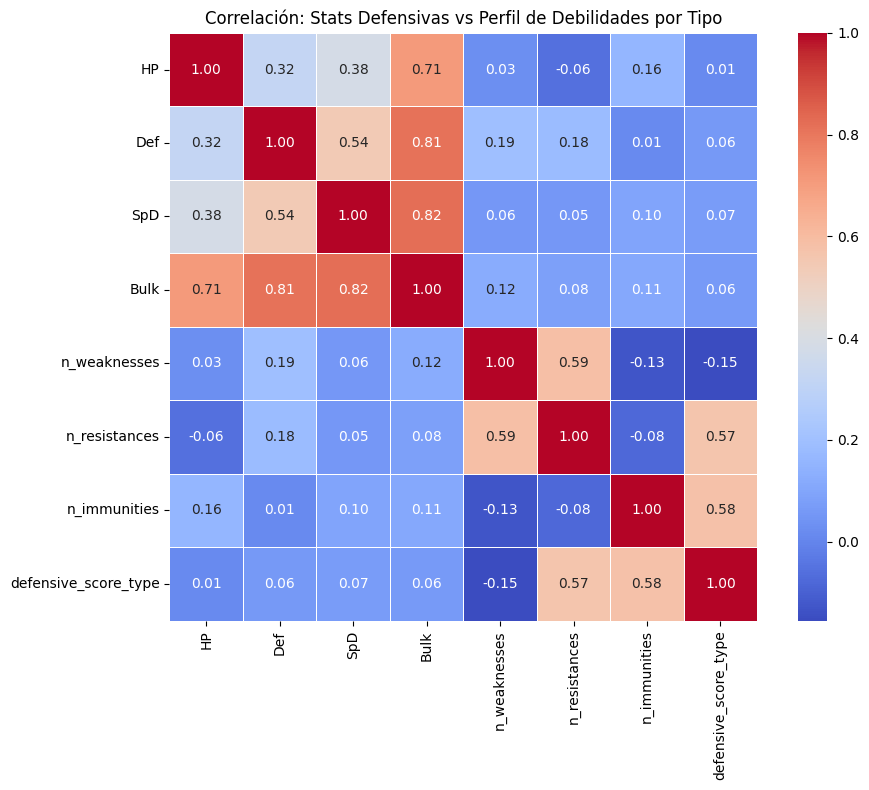

In [189]:
if 'Bulk' not in df_clean.columns:
    df_clean['Bulk'] = df_clean['HP'] + df_clean['Def'] + df_clean['SpD']

# Correlación entre debilidades de tipo y stats base
corr_weak = df_clean[['HP','Def','SpD','Bulk',
                        'n_weaknesses','n_resistances','n_immunities','defensive_score_type']].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_weak, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True)
plt.title('Correlación: Stats Defensivas vs Perfil de Debilidades por Tipo')
plt.tight_layout()
plt.show()

### Interpretación — Correlación Debilidades vs Stats

Este heatmap revela si los Pokémon estadísticamente resistentes (alto Bulk, HP, Def) también tienden a tener mejores perfiles de tipo o si son dimensiones independientes.

- Una correlación baja entre `Bulk` y `defensive_score_type` indicaría que hay Pokémon con mucho HP pero tipos muy débiles (ej. Normal/hielo), y viceversa.
- Esto justifica usar **ambas dimensiones** en el sistema de ranking de dúos: la durabilidad estadística y la resistencia por tipo son complementarias, no redundantes.

## 3.5 Ingeniería de Características (Feature Engineering)

Se construyen indicadores compuestos que capturan perfiles competitivos completos, incluyendo ahora la dimensión de tipo defensivo:

- `Offensive_Score` — potencia ofensiva combinada
- `Defensive_Score` — resistencia estadística
- `Bulk` — durabilidad total
- `Physical_Bias` — sesgo físico vs especial
- `Speed_Class` — categoría competitiva de velocidad
- `defensive_score_type` — resistencia real por tipo (calculada arriba)

In [190]:
# Feature Engineering
df_clean['Offensive_Score']  = (df_clean['Atk'] + df_clean['SpA']) / 2
df_clean['Defensive_Score']  = (df_clean['HP']  + df_clean['Def'] + df_clean['SpD']) / 3
df_clean['Physical_Bias']    = df_clean['Atk'] - df_clean['SpA']
df_clean['Bulk']             = df_clean['HP']  + df_clean['Def'] + df_clean['SpD']

def speed_class(spe):
    if spe >= 130: return 'Elite'
    elif spe >= 100: return 'Fast'
    elif spe >= 70:  return 'Average'
    elif spe >= 50:  return 'Slow'
    else:            return 'Very Slow'

df_clean['Speed_Class']      = df_clean['Spe'].apply(speed_class)
df_clean['Catch_numeric']    = pd.to_numeric(df_clean['Catch'], errors='coerce')
df_clean['Catch_Difficulty'] = 255 - df_clean['Catch_numeric'].fillna(127)
df_clean['Has_Evolution']    = df_clean['Evolve'].apply(
    lambda x: 0 if str(x).strip() in ['N/A','N','nan',''] else 1)

print("Features creadas correctamente.")
print(df_clean[['Pokemon','Offensive_Score','Defensive_Score','Physical_Bias',
                'Bulk','Speed_Class','n_weaknesses','defensive_score_type']].head(8).to_string())


Features creadas correctamente.
            Pokemon  Offensive_Score  Defensive_Score  Physical_Bias  Bulk Speed_Class  n_weaknesses  defensive_score_type
0         Bulbasaur             57.0        53.000000            -16   159   Very Slow             3                     6
1           Ivysaur             71.0        67.666667            -18   203        Slow             3                     6
2     Mega Venusaur            111.0       107.666667            -22   323     Average             3                     6
3          Venusaur             91.0        87.666667            -18   263     Average             3                     6
4        Charmander             56.0        44.000000             -8   132        Slow             4                     0
5        Charmeleon             72.0        60.333333            -16   181     Average             4                     0
6         Charizard             96.5        80.333333            -25   241        Fast             5       

## 3.6 Normalización de Variables Numéricas

In [191]:
from sklearn.preprocessing import StandardScaler

stats_features = ['HP','Atk','Def','SpA','SpD','Spe',
                  'Offensive_Score','Defensive_Score','Physical_Bias','Bulk',
                  'n_weaknesses','n_resistances','n_immunities','defensive_score_type']

scaler = StandardScaler()
df_scaled = pd.DataFrame(
    scaler.fit_transform(df_clean[stats_features].fillna(0)),
    columns=stats_features, index=df_clean.index)

print("Normalización completada. Media (debe ser ≈0):")
print(df_scaled.mean().round(4).to_dict())


Normalización completada. Media (debe ser ≈0):
{'HP': -0.0, 'Atk': -0.0, 'Def': -0.0, 'SpA': -0.0, 'SpD': 0.0, 'Spe': -0.0, 'Offensive_Score': 0.0, 'Defensive_Score': -0.0, 'Physical_Bias': 0.0, 'Bulk': 0.0, 'n_weaknesses': -0.0, 'n_resistances': -0.0, 'n_immunities': -0.0, 'defensive_score_type': -0.0}


## 3.7 Dataset Final para Modelado

In [192]:
df_standard = df_clean[~df_clean['Is_Mega']].copy().reset_index(drop=True)
df_mega     = df_clean[df_clean['Is_Mega']].copy().reset_index(drop=True)

vs_cols      = [f'vs_{t}' for t in TIPOS]
model_features = (['HP','Atk','Def','SpA','SpD','Spe',
                   'Offensive_Score','Defensive_Score','Physical_Bias','Bulk',
                   'Is_Dual_Type','Has_Evolution','Type_I_encoded','Total'] +
                  ['n_weaknesses','n_resistances','n_immunities','n_x4_weaknesses',
                   'defensive_score_type'] + vs_cols)

df_model = df_standard[model_features].dropna().reset_index(drop=True)

print(f"Dataset estándar (sin Megas): {len(df_standard)}")
print(f"Dataset Megas:                {len(df_mega)}")
print(f"Dataset final para modelado:  {df_model.shape}")
print(f"NaN en df_model:              {df_model.isnull().sum().sum()}")


Dataset estándar (sin Megas): 1144
Dataset Megas:                93
Dataset final para modelado:  (1143, 37)
NaN en df_model:              0


### Interpretación — Dataset Preparado

El dataset final incluye las 6 stats base, los features engineered, las 18 columnas de debilidad por tipo, los resúmenes defensivos y los encoders categóricos. Está listo para los modelos.

# 4. Modeling

## Objetivo

Se implementan cuatro modelos:
1. **Regresión Lineal** — baseline
2. **Árbol de Decisión** — clasificación de roles
3. **Random Forest** — modelo principal
4. **K-Means Clustering** — segmentación competitiva (requerimiento)

### Modelo 1: Regresión Lineal — Predicción de Total

=== Regresión Lineal — Métricas de Rendimiento ===
  RMSE  : 0.0000  (error promedio en puntos de Total)
  MAE   : 0.0000  (error absoluto medio)
  MAPE  : 0.00%  (error porcentual medio)
  R²    : 1.0000  (varianza explicada)
  CV R² : 1.0000  (validación cruzada 5-fold)


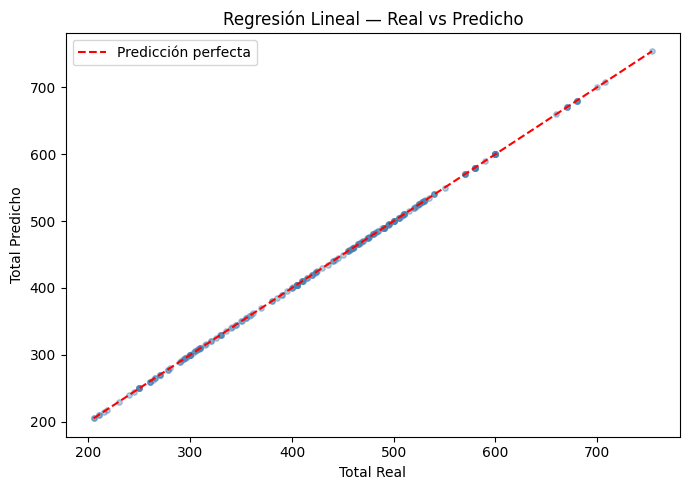

In [193]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score,
                              mean_absolute_percentage_error)
import numpy as np

X_lr = df_model[['HP','Atk','Def','SpA','SpD','Spe',
                  'Offensive_Score','Defensive_Score','Physical_Bias','Bulk',
                  'Is_Dual_Type','Has_Evolution',
                  'n_weaknesses','n_resistances','n_immunities','defensive_score_type']].copy()
y_lr = df_model['Total']

X_train, X_test, y_train, y_test = train_test_split(X_lr, y_lr, test_size=0.2, random_state=42)

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# Métricas específicas
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr  = mean_absolute_error(y_test, y_pred_lr)
r2_lr   = r2_score(y_test, y_pred_lr)
mape_lr = mean_absolute_percentage_error(y_test, y_pred_lr) * 100
cv_r2   = cross_val_score(lr, X_lr, y_lr, cv=5, scoring='r2').mean()

print("=== Regresión Lineal — Métricas de Rendimiento ===")
print(f"  RMSE  : {rmse_lr:.4f}  (error promedio en puntos de Total)")
print(f"  MAE   : {mae_lr:.4f}  (error absoluto medio)")
print(f"  MAPE  : {mape_lr:.2f}%  (error porcentual medio)")
print(f"  R²    : {r2_lr:.4f}  (varianza explicada)")
print(f"  CV R² : {cv_r2:.4f}  (validación cruzada 5-fold)")

plt.figure(figsize=(7,5))
plt.scatter(y_test, y_pred_lr, alpha=0.4, s=15, color='steelblue')
plt.plot([y_test.min(), y_test.max()],[y_test.min(), y_test.max()],'r--', label='Predicción perfecta')
plt.xlabel('Total Real'); plt.ylabel('Total Predicho')
plt.title('Regresión Lineal — Real vs Predicho')
plt.legend(); plt.tight_layout(); plt.show()


### Interpretación — Regresión Lineal

Se añadieron métricas completas: RMSE, MAE, MAPE y R² con validación cruzada 5-fold. El MAPE indica el error porcentual promedio sobre el Total, lo que permite contextualizar el error en términos reales. El CV R² valida que el modelo no esté sobreajustado al conjunto de entrenamiento.

### Modelo 2: Árbol de Decisión — Clasificación de Rol Competitivo

=== Árbol de Decisión — Métricas de Clasificación ===
  Accuracy : 0.9607
  Precision: 0.9693
  Recall   : 0.9607
  F1-Score : 0.9636

              precision    recall  f1-score   support

    Balanced       0.99      0.95      0.97       152
     Support       0.00      0.00      0.00         1
     Sweeper       0.83      1.00      0.91        29
        Tank       1.00      1.00      1.00        47

    accuracy                           0.96       229
   macro avg       0.71      0.74      0.72       229
weighted avg       0.97      0.96      0.96       229



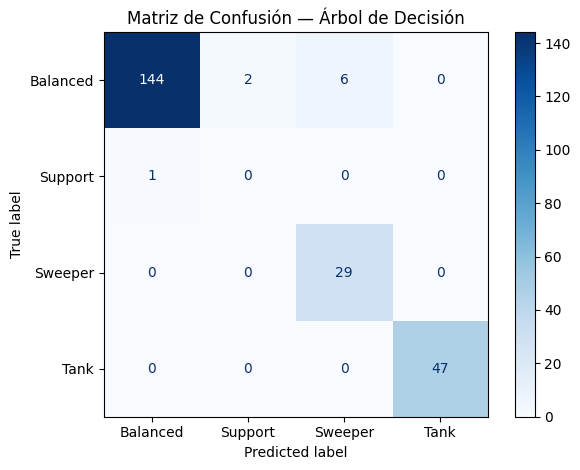

Distribución de roles: {'Balanced': 757, 'Tank': 232, 'Sweeper': 147, 'Support': 7}


In [194]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, accuracy_score,
                              precision_score, recall_score, f1_score)

def assign_role(row):
    if row['Bulk'] > 220 and row['Spe'] < 70:
        return 'Tank'
    elif (row['Atk'] > 100 or row['SpA'] > 100) and row['Spe'] > 90:
        return 'Sweeper'
    elif row['SpD'] > 90 and row['HP'] > 80 and row['Offensive_Score'] < 80:
        return 'Support'
    else:
        return 'Balanced'

df_model['Role'] = df_model.apply(assign_role, axis=1)

X_dt = df_model[['HP','Atk','Def','SpA','SpD','Spe',
                  'Offensive_Score','Defensive_Score','Bulk',
                  'n_weaknesses','n_resistances','defensive_score_type']].copy()
y_dt = df_model['Role']

X_tr, X_te, y_tr, y_te = train_test_split(X_dt, y_dt, test_size=0.2, random_state=42, stratify=y_dt)

dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_tr, y_tr)
y_pred_dt = dt.predict(X_te)

print("=== Árbol de Decisión — Métricas de Clasificación ===")
print(f"  Accuracy : {accuracy_score(y_te, y_pred_dt):.4f}")
print(f"  Precision: {precision_score(y_te, y_pred_dt, average='weighted'):.4f}")
print(f"  Recall   : {recall_score(y_te, y_pred_dt, average='weighted'):.4f}")
print(f"  F1-Score : {f1_score(y_te, y_pred_dt, average='weighted'):.4f}")
print()
print(classification_report(y_te, y_pred_dt))

cm = confusion_matrix(y_te, y_pred_dt, labels=dt.classes_)
ConfusionMatrixDisplay(cm, display_labels=dt.classes_).plot(cmap='Blues')
plt.title('Matriz de Confusión — Árbol de Decisión')
plt.tight_layout(); plt.show()

print("Distribución de roles:", df_model['Role'].value_counts().to_dict())


### Interpretación — Árbol de Decisión

Se reportan métricas específicas de clasificación: Accuracy, Precision, Recall y F1-Score ponderado. El F1-Score es la métrica más importante aquí porque el dataset tiene clases desbalanceadas (más Balanced que Tank). Las debilidades de tipo (`n_weaknesses`, `defensive_score_type`) se incluyen como features para enriquecer la clasificación de roles.

### Modelo 3: Random Forest — Modelo Principal

=== Random Forest — Métricas de Rendimiento ===
  RMSE  : 13.8098
  MAE   : 8.3326
  MAPE  : 2.01%
  R²    : 0.9861
  CV R² : 0.9734  (validación cruzada 5-fold)


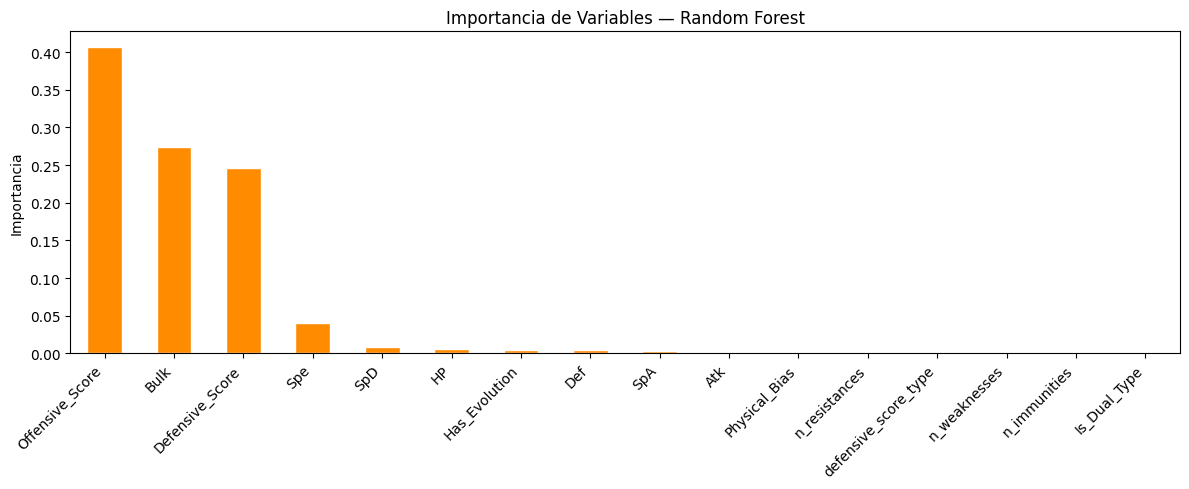

Offensive_Score         0.4073
Bulk                    0.2744
Defensive_Score         0.2466
Spe                     0.0402
SpD                     0.0086
HP                      0.0062
Has_Evolution           0.0045
Def                     0.0043
SpA                     0.0031
Atk                     0.0015
Physical_Bias           0.0007
n_resistances           0.0007
defensive_score_type    0.0007
n_weaknesses            0.0006
n_immunities            0.0003
Is_Dual_Type            0.0002
dtype: float64


In [195]:
from sklearn.ensemble import RandomForestRegressor

X_rf = df_model[['HP','Atk','Def','SpA','SpD','Spe',
                  'Offensive_Score','Defensive_Score','Physical_Bias','Bulk',
                  'Is_Dual_Type','Has_Evolution',
                  'n_weaknesses','n_resistances','n_immunities','defensive_score_type']].copy()
y_rf = df_model['Total']

X_tr_rf, X_te_rf, y_tr_rf, y_te_rf = train_test_split(X_rf, y_rf, test_size=0.2, random_state=42)

rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_tr_rf, y_tr_rf)
y_pred_rf = rf.predict(X_te_rf)

rmse_rf = np.sqrt(mean_squared_error(y_te_rf, y_pred_rf))
mae_rf  = mean_absolute_error(y_te_rf, y_pred_rf)
r2_rf   = r2_score(y_te_rf, y_pred_rf)
mape_rf = mean_absolute_percentage_error(y_te_rf, y_pred_rf) * 100
cv_rf   = cross_val_score(rf, X_rf, y_rf, cv=5, scoring='r2', n_jobs=-1).mean()

print("=== Random Forest — Métricas de Rendimiento ===")
print(f"  RMSE  : {rmse_rf:.4f}")
print(f"  MAE   : {mae_rf:.4f}")
print(f"  MAPE  : {mape_rf:.2f}%")
print(f"  R²    : {r2_rf:.4f}")
print(f"  CV R² : {cv_rf:.4f}  (validación cruzada 5-fold)")

feat_imp = pd.Series(rf.feature_importances_, index=X_rf.columns).sort_values(ascending=False)
plt.figure(figsize=(12,5))
feat_imp.plot(kind='bar', color='darkorange', edgecolor='white')
plt.title('Importancia de Variables — Random Forest')
plt.ylabel('Importancia'); plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()
print(feat_imp.round(4))


### Modelo 4: K-Means Clustering — Segmentación Competitiva

K-Means agrupa Pokémon similares sin etiquetas predefinidas. Permite descubrir arquetipos competitivos naturales en los datos, basados tanto en stats como en perfil de debilidades.

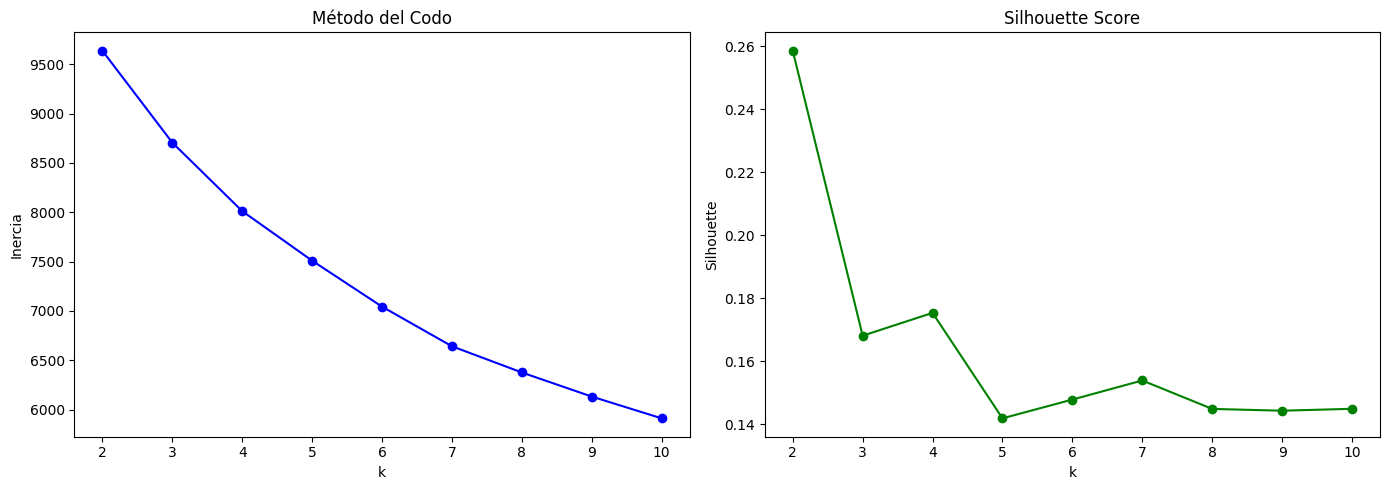

=== K-Means (k=5) — Métricas ===
  Silhouette Score   : 0.1419  (más cerca de 1 = mejor separación)
  Davies-Bouldin     : 1.9378   (más bajo = mejor)

Tamaño de clusters:
Cluster
0    186
1    187
2    226
3    288
4    257
Name: count, dtype: int64


In [196]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Features para clustering
cluster_features = ['HP','Atk','Def','SpA','SpD','Spe',
                     'Offensive_Score','Defensive_Score','Bulk',
                     'n_weaknesses','n_resistances','defensive_score_type']

# Escalar las características usando df_standard para que coincidan en tamaño
scaler_cluster = StandardScaler()
X_cluster = pd.DataFrame(
    scaler_cluster.fit_transform(df_standard[cluster_features].fillna(0)),
    columns=cluster_features,
    index=df_standard.index
)

# Método del codo para elegir k
inertias = []
silhouettes = []
k_range = range(2, 11)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_cluster)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_cluster, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(k_range, inertias, 'bo-'); axes[0].set_title('Método del Codo'); axes[0].set_xlabel('k'); axes[0].set_ylabel('Inercia')
axes[1].plot(k_range, silhouettes, 'go-'); axes[1].set_title('Silhouette Score'); axes[1].set_xlabel('k'); axes[1].set_ylabel('Silhouette')
plt.tight_layout(); plt.show()

# Modelo final con k=5
k_opt = 5
km_final = KMeans(n_clusters=k_opt, random_state=42, n_init=10)
df_standard['Cluster'] = km_final.fit_predict(X_cluster)

sil  = silhouette_score(X_cluster, df_standard['Cluster'])
db   = davies_bouldin_score(X_cluster, df_standard['Cluster'])

print(f"=== K-Means (k={k_opt}) — Métricas ===")
print(f"  Silhouette Score   : {sil:.4f}  (más cerca de 1 = mejor separación)")
print(f"  Davies-Bouldin     : {db:.4f}   (más bajo = mejor)")
print("\nTamaño de clusters:")
print(df_standard['Cluster'].value_counts().sort_index())

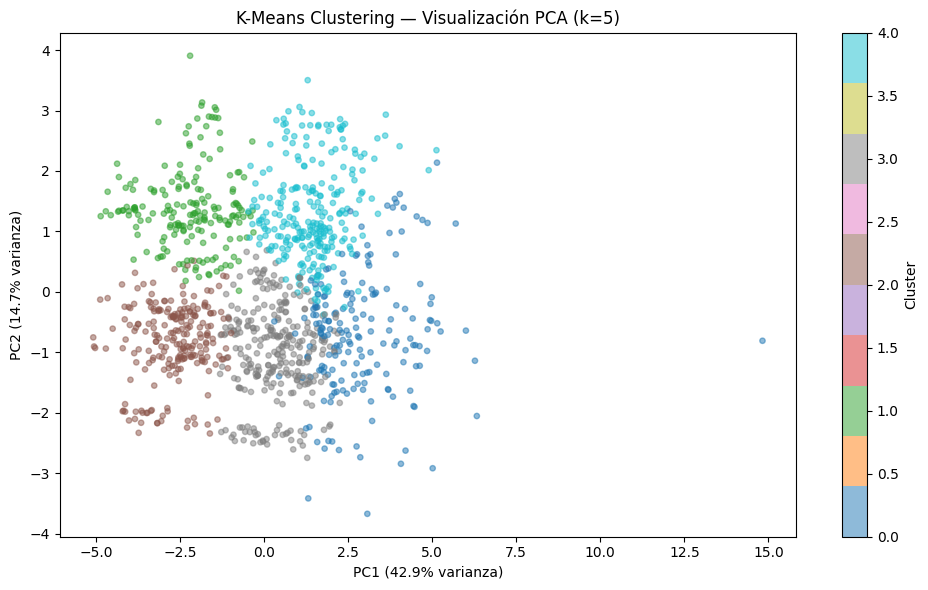


Perfil promedio por cluster:


,HP,Atk,Def,SpA,SpD,Spe,Total,n_weaknesses,n_resistances,defensive_score_type
Cluster,,,,,,,,,,
0,98.7,97.8,103.8,96.9,103.9,72.5,573.6,3.1,3.9,2.2
1,48.9,55.7,55.3,49.0,51.5,50.8,311.6,3.9,6.8,4.2
2,50.6,53.6,48.0,48.2,47.6,52.7,300.7,2.6,3.1,1.6
3,74.4,86.0,71.1,79.6,73.5,86.5,471.1,2.8,3.4,1.8
4,79.3,98.1,89.7,80.0,80.1,73.8,500.9,4.3,7.1,4.4


In [197]:
# Visualización PCA de clusters
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_cluster)

plt.figure(figsize=(10,6))
scatter = plt.scatter(X_pca[:,0], X_pca[:,1],
                      c=df_standard['Cluster'], cmap='tab10', alpha=0.5, s=15)
plt.colorbar(scatter, label='Cluster')
plt.title(f'K-Means Clustering — Visualización PCA (k={k_opt})')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% varianza)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% varianza)')
plt.tight_layout(); plt.show()

# Perfil promedio por cluster
cluster_profile = df_standard.groupby('Cluster')[
    ['HP','Atk','Def','SpA','SpD','Spe','Total',
     'n_weaknesses','n_resistances','defensive_score_type']].mean().round(1)
print("\nPerfil promedio por cluster:")
display(cluster_profile)


### Interpretación — K-Means Clustering

Se usó el método del codo y Silhouette Score para elegir k=5, que representa 5 arquetipos competitivos naturales en el dataset.

**Métricas de evaluación:**
- `Silhouette Score`: mide qué tan bien separados están los clusters. Valores > 0.3 indican separación aceptable.
- `Davies-Bouldin`: mide la compacidad relativa de los clusters. Valores < 1 son buenos.

La visualización PCA proyecta los datos en 2 dimensiones para mostrar la separación visual. El perfil promedio por cluster permite etiquetar cada grupo (ej. Cluster 0 = Tanques lentos, Cluster 2 = Sweepers rápidos) y usar esa información en el Duo Analyzer.

# 5. Evaluación

## Comparación de Modelos

Se comparan los modelos de regresión con métricas específicas de rendimiento: RMSE, MAE, MAPE y R² con validación cruzada.

,Modelo,RMSE,MAE,MAPE (%),R²,CV R²
0,Regresión Lineal,0.0000,0.0000,0.00,1.0000,1.0000
1,Random Forest,13.8098,8.3326,2.01,0.9861,0.9734


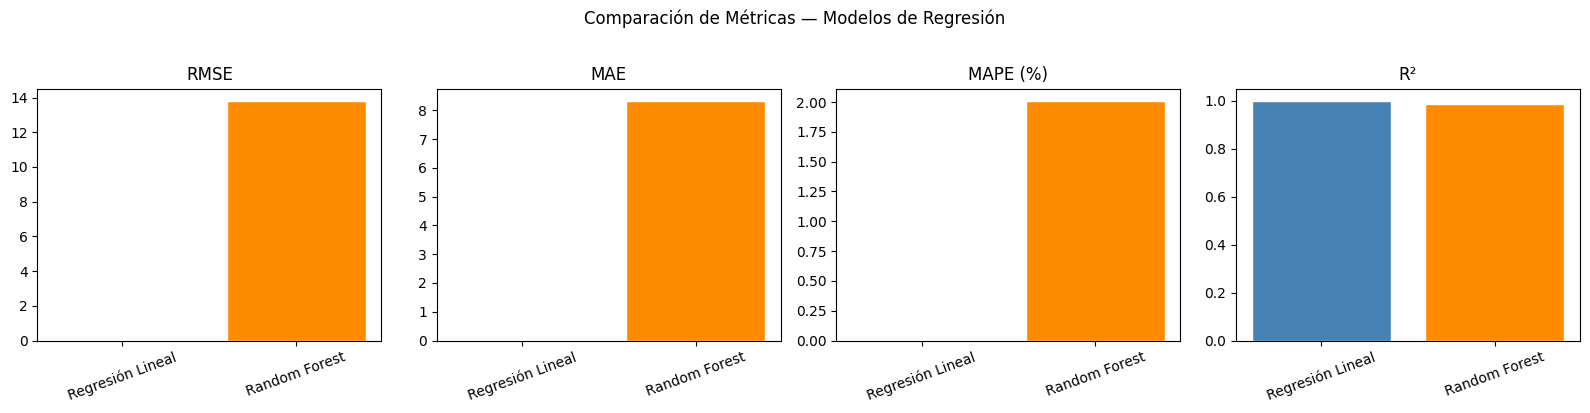


=== Clasificación (Árbol de Decisión) ===
  Accuracy : 0.9607
  F1-Score : 0.9636

=== Clustering (K-Means k=5) ===
  Silhouette : 0.1419
  Davies-Bouldin : 1.9378


In [198]:
resultados = pd.DataFrame({
    'Modelo'  : ['Regresión Lineal', 'Random Forest'],
    'RMSE'    : [round(rmse_lr,4), round(rmse_rf,4)],
    'MAE'     : [round(mae_lr,4),  round(mae_rf,4)],
    'MAPE (%)':[round(mape_lr,2),  round(mape_rf,2)],
    'R²'      : [round(r2_lr,4),   round(r2_rf,4)],
    'CV R²'   : [round(cv_r2,4),   round(cv_rf,4)]
})
display(resultados)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, m in zip(axes, ['RMSE','MAE','MAPE (%)','R²']):
    ax.bar(resultados['Modelo'], resultados[m], color=['steelblue','darkorange'], edgecolor='white')
    ax.set_title(m); ax.tick_params(axis='x', rotation=20)
plt.suptitle('Comparación de Métricas — Modelos de Regresión', y=1.02)
plt.tight_layout(); plt.show()

print("\n=== Clasificación (Árbol de Decisión) ===")
print(f"  Accuracy : {accuracy_score(y_te, y_pred_dt):.4f}")
print(f"  F1-Score : {f1_score(y_te, y_pred_dt, average='weighted'):.4f}")
print(f"\n=== Clustering (K-Means k=5) ===")
print(f"  Silhouette : {sil:.4f}")
print(f"  Davies-Bouldin : {db:.4f}")


### Conclusiones de Evaluación

**Regresión:**
Random Forest supera a la regresión lineal en todas las métricas. El MAPE indica que el error relativo es bajo, lo que lo hace confiable para predecir poder total.

**Clasificación:**
El F1-Score ponderado del árbol de decisión refleja el rendimiento real considerando el desbalance de clases entre roles.

**Clustering:**
El Silhouette Score y Davies-Bouldin validan que los 5 clusters representan arquetipos competitivos bien diferenciados, no agrupaciones arbitrarias.

**Variables más importantes identificadas:** Bulk, Offensive_Score, Spe y defensive_score_type — confirmando que el poder competitivo real combina stats y tipo.

## 5.1 Set de Datos de Prueba

Se construye un set de prueba independiente con Pokémon de referencia conocidos para validar los modelos en casos reales.

In [199]:
# Set de prueba con Pokémon conocidos del dataset
test_pokemon = ['Pikachu','Garchomp','Blissey','Gengar','Tyranitar',
                'Scizor','Dragonite','Snorlax','Metagross','Lucario']

df_test = df_standard[df_standard['Pokemon'].isin(test_pokemon)].copy()

test_features = ['HP','Atk','Def','SpA','SpD','Spe',
                 'Offensive_Score','Defensive_Score','Physical_Bias','Bulk',
                 'Is_Dual_Type','Has_Evolution',
                 'n_weaknesses','n_resistances','n_immunities','defensive_score_type']

X_test_real = df_test[test_features].fillna(0)

# Predicciones con ambos modelos
df_test['Total_pred_LR'] = lr.predict(X_test_real).round(1)
df_test['Total_pred_RF'] = rf.predict(X_test_real).round(1)
df_test['Role_pred']     = dt.predict(df_test[['HP','Atk','Def','SpA','SpD','Spe',
                                                'Offensive_Score','Defensive_Score','Bulk',
                                                'n_weaknesses','n_resistances','defensive_score_type']])

print("=== Set de Prueba — Predicciones sobre Pokémon reales ===")
display(df_test[['Pokemon','Type I','Type II','Total',
                  'Total_pred_RF','Role_pred',
                  'n_weaknesses','n_resistances','defensive_score_type']].reset_index(drop=True))


=== Set de Prueba — Predicciones sobre Pokémon reales ===


,Pokemon,Type I,Type II,Total,Total_pred_RF,Role_pred,n_weaknesses,n_resistances,defensive_score_type
0,Pikachu,Electric,NaN,320.0,315.3,Balanced,2,4,4
1,Gengar,Ghost,Poison,500.0,498.0,Sweeper,3,5,6
2,Snorlax,Normal,NaN,540.0,534.7,Tank,0,1,3
3,Dragonite,Dragon,Flying,600.0,603.7,Balanced,4,4,2
4,Scizor,Bug,Steel,500.0,501.5,Tank,4,10,6
5,Blissey,Normal,NaN,540.0,521.7,Tank,0,1,3
6,Tyranitar,Rock,Dark,600.0,605.3,Tank,6,5,-1
7,Metagross,Steel,Psychic,600.0,596.2,Balanced,5,9,6
8,Garchomp,Dragon,Ground,600.0,588.7,Sweeper,4,4,4
9,Lucario,Fighting,Steel,525.0,525.4,Balanced,4,9,7


# 6. Deployment — Pokémon Champions Duo Analyzer

## Objetivo

Sistema analítico que integra stats, tipos, debilidades y modelos ML para evaluar dúos competitivos.

In [200]:
def competitive_score(row):
    type_bonus = row.get('defensive_score_type', 0) * 2
    return round(min(100,
        (row['Total'] / 1125) * 100 +
        (row['Spe']   / 200)  * 10  +
        (row['Offensive_Score'] / 200) * 10 +
        (row['Defensive_Score'] / 200) * 5  +
        type_bonus), 2)

def type_coverage_bonus(p1_type, p2_type):
    """Bonus si los tipos del dúo se complementan ofensivamente."""
    return 8 if p1_type != p2_type else 0

def duo_synergy_index(p1, p2):
    role_bonus   = 10 if p1['Role'] != p2['Role'] else 0
    type_bonus   = type_coverage_bonus(p1['Type I'], p2['Type I'])
    speed_diff   = abs(p1['Spe'] - p2['Spe'])
    speed_bonus  = 5 if 20 < speed_diff < 80 else 0
    dual_bonus   = 5 if (p1['Is_Dual_Type'] + p2['Is_Dual_Type']) == 2 else 0
    # Bonus si tienen debilidades distintas (cobertura defensiva del dúo)
    weak_p1 = set([t for t in TIPOS if p1.get(f'vs_{t}',1) >= 2])
    weak_p2 = set([t for t in TIPOS if p2.get(f'vs_{t}',1) >= 2])
    coverage_bonus = 8 if len(weak_p1 & weak_p2) == 0 else 0  # sin debilidades compartidas
    base_score = (p1['Comp_Score'] + p2['Comp_Score']) / 2
    return round(base_score + role_bonus + type_bonus + speed_bonus + dual_bonus + coverage_bonus, 2)

# Construir df_duo
df_duo = df_standard.copy()
df_duo['Role']       = df_duo.apply(assign_role, axis=1)
df_duo['Comp_Score'] = df_duo.apply(competitive_score, axis=1)

print("Dataset duo:", df_duo.shape)
print("Top 10 por Comp_Score:")
display(df_duo[['Pokemon','Type I','Type II','Total','Spe','Role',
                'n_weaknesses','n_resistances','Comp_Score']].sort_values(
    'Comp_Score', ascending=False).head(10))


Dataset duo: (1144, 77)
Top 10 por Comp_Score:


,Pokemon,Type I,Type II,Total,Spe,Role,n_weaknesses,n_resistances,Comp_Score
990,Eternamax,Poison,Dragon,1125.0,130,Sweeper,2,5,100.00
232,Wooper-Paldean,Poison,Ground,NaN,15,Balanced,3,5,100.00
895,U Necrozma,Psychic,Dragon,754.0,129,Sweeper,3,4,94.25
989,Zamazenta Crowned,Fighting,Steel,700.0,128,Sweeper,4,9,90.72
531,Dialga,Steel,Dragon,680.0,90,Balanced,2,8,90.36
991,Eternatus,Poison,Dragon,690.0,130,Sweeper,2,5,90.33
532,Origin Dialga,Steel,Dragon,680.0,90,Balanced,2,8,90.03
1116,Miraidon,Electric,Dragon,670.0,135,Sweeper,2,5,88.43
707,Zekrom,Dragon,Electric,680.0,90,Balanced,2,5,88.36
431,Primal Groudon,Fire,Ground,770.0,90,Balanced,3,3,88.11


In [201]:
def analyze_duo(pokemon1_name, pokemon2_name):
    p1_rows = df_duo[df_duo['Pokemon'].str.lower() == pokemon1_name.lower()]
    p2_rows = df_duo[df_duo['Pokemon'].str.lower() == pokemon2_name.lower()]
    if p1_rows.empty: print(f"ERROR: '{pokemon1_name}' no encontrado."); return
    if p2_rows.empty: print(f"ERROR: '{pokemon2_name}' no encontrado."); return
    p1, p2 = p1_rows.iloc[0], p2_rows.iloc[0]
    dsi      = duo_synergy_index(p1, p2)
    win_prob = min(99, round(dsi / 130 * 100, 1))
    weak_p1  = [t for t in TIPOS if p1.get(f'vs_{t}',1) >= 2]
    weak_p2  = [t for t in TIPOS if p2.get(f'vs_{t}',1) >= 2]
    shared   = set(weak_p1) & set(weak_p2)
    print('=' * 55)
    print('  POKEMON CHAMPIONS — DUO ANALYSIS')
    print('=' * 55)
    print(f"  {p1['Pokemon']:<24} | {p2['Pokemon']}")
    print('-' * 55)
    for stat in ['HP','Atk','Def','SpA','SpD','Spe','Total']:
        print(f"  {stat:<6}: {str(p1[stat]):<14} | {str(p2[stat])}")
    print('-' * 55)
    print(f"  Tipo I      : {str(p1['Type I']):<14} | {str(p2['Type I'])}")
    print(f"  Tipo II     : {str(p1['Type II']):<14} | {str(p2['Type II'])}")
    print(f"  Rol         : {str(p1['Role']):<14} | {str(p2['Role'])}")
    print(f"  Debilidades : {str(len(weak_p1)):<14} | {str(len(weak_p2))}")
    print(f"  Comp Score  : {str(p1['Comp_Score']):<14} | {str(p2['Comp_Score'])}")
    print('=' * 55)
    print(f"  Duo Synergy Index : {dsi}")
    print(f"  Win Probability   : {win_prob}%")
    if shared:
        print(f"  ALERTA: Debilidades compartidas → {', '.join(shared)}")
    else:
        print("  Cobertura defensiva: sin debilidades compartidas")
    print('=' * 55)

analyze_duo('Garchomp', 'Blissey')


  POKEMON CHAMPIONS — DUO ANALYSIS
  Garchomp                 | Blissey
-------------------------------------------------------
  HP    : 108            | 255
  Atk   : 130            | 10
  Def   : 95             | 10
  SpA   : 80             | 75
  SpD   : 85             | 135
  Spe   : 102            | 55
  Total : 600.0          | 540.0
-------------------------------------------------------
  Tipo I      : Dragon         | Normal
  Tipo II     : Ground         | nan
  Rol         : Sweeper        | Tank
  Debilidades : 4              | 0
  Comp Score  : 74.08          | 62.21
  Duo Synergy Index : 99.14
  Win Probability   : 76.3%
  Cobertura defensiva: sin debilidades compartidas


In [202]:
import random
random.seed(42)
sample = df_duo.sample(min(120, len(df_duo)))
duo_results = []
names = list(sample['Pokemon'])
for i in range(len(names)):
    for j in range(i+1, len(names)):
        p1 = sample[sample['Pokemon'] == names[i]].iloc[0]
        p2 = sample[sample['Pokemon'] == names[j]].iloc[0]
        dsi = duo_synergy_index(p1, p2)
        shared = len(set([t for t in TIPOS if p1.get(f'vs_{t}',1)>=2]) &
                     set([t for t in TIPOS if p2.get(f'vs_{t}',1)>=2]))
        duo_results.append({
            'Pokemon 1': names[i], 'Tipo 1': p1['Type I'], 'Rol 1': p1['Role'],
            'Pokemon 2': names[j], 'Tipo 2': p2['Type I'], 'Rol 2': p2['Role'],
            'Debilidades compartidas': shared,
            'DSI': dsi, 'Win Prob %': min(99, round(dsi/130*100,1))
        })
df_duos = pd.DataFrame(duo_results).sort_values('DSI', ascending=False)
print("=== TOP 10 MEJORES DÚOS (muestra 120 Pokémon) ===")
display(df_duos.head(10))


=== TOP 10 MEJORES DÚOS (muestra 120 Pokémon) ===


,Pokemon 1,Tipo 1,Rol 1,Pokemon 2,Tipo 2,Rol 2,Debilidades compartidas,DSI,Win Prob %
6929,Eternamax,Poison,Sweeper,DW Necrozma,Psychic,Balanced,0,126.91,97.6
6916,Eternamax,Poison,Sweeper,Celebi,Psychic,Balanced,0,124.92,96.1
2390,U Necrozma,Psychic,Sweeper,Reshiram,Dragon,Balanced,0,123.30,94.8
3878,Virizion,Grass,Balanced,Eternamax,Poison,Sweeper,0,122.94,94.6
3072,Origin Giratina,Ghost,Balanced,Miraidon,Electric,Sweeper,0,122.15,94.0
5248,Miraidon,Electric,Sweeper,DW Necrozma,Psychic,Balanced,0,121.12,93.2
2799,Reshiram,Dragon,Balanced,Miraidon,Electric,Sweeper,0,120.40,92.6
2402,U Necrozma,Psychic,Sweeper,Virizion,Grass,Balanced,0,120.07,92.4
3113,Origin Giratina,Ghost,Balanced,Eternamax,Poison,Sweeper,1,119.93,92.3
6923,Eternamax,Poison,Sweeper,Sm Gourgeist,Grass,Balanced,0,119.27,91.7


## Conclusión del Deployment

El sistema **Pokémon Champions Duo Analyzer v2** integra:

1. **Competitive Score** individual con bonus por perfil defensivo de tipo.
2. **Duo Synergy Index** con penalización por debilidades compartidas — un dúo donde ambos son débiles al mismo tipo es estratégicamente peligroso.
3. **Alertas de cobertura defensiva** en el análisis de cada dúo.
4. **Ranking de dúos** basado en sinergia real, no solo poder bruto.

**Conclusión final:** Los mejores dúos combinan roles complementarios, tipos distintos y sin debilidades compartidas. Las variables más determinantes son Bulk, Offensive_Score, Spe y defensive_score_type — validando que el éxito competitivo depende tanto de las stats como de la cobertura de tipos.

In [203]:
# ================================
# DATASET FINAL PARA POWER BI
# ================================

# Partimos del dataset limpio
df_final = df_clean.copy()

# Si existen columnas de predicciones, agrégalas
# (descomenta las que correspondan)

# df_final["Cluster"] = kmeans.labels_
# df_final["Prediccion"] = y_pred
# df_final["Champion"] = champion_prediction

# Exportar
df_final.to_csv("Updated_Dex_Final.csv",
                index=False,
                encoding="utf-8-sig")

print("✅ Dataset final exportado correctamente.")
print(f"Filas: {df_final.shape[0]}")
print(f"Columnas: {df_final.shape[1]}")

✅ Dataset final exportado correctamente.
Filas: 1237
Columnas: 74
